# AIPA-CRS: Adaptive Intent-Preference Arbitration for Conversational Recommendation

**Research implementation notebook** - reproducible experimental foundation for the AIPA-CRS study.

## Research design

| Item | Content |
|---|---|
| Problem | Conversational recommenders must reconcile a user's **long-term preference (LTP)** (earlier sessions) with the **short-term intent (STI)** expressed in the current dialogue. Naive fusion treats both as always compatible. |
| Research question | Does *explicit* intent-preference arbitration improve recommendation quality **specifically when STI conflicts with LTP**? |
| Hypotheses | H1 overall gain over LTP-only / STI-only / naive fusion; H2 gain concentrated on Conflict/Override instances; H3 every AIPA component contributes (ablations); H4 the relationship classifier is above chance and calibrated. |
| Relationship taxonomy | Complement, Consistent, Conflict, Override, Uncertain |
| Arbitration actions | Fuse, Prioritize_LTP, Prioritize_STI, Ask_Clarification |
| Dataset | **ReDial** (English, human-human movie recommendation dialogues; seekers recur across dialogues, which is used to build cross-session LTP). MovieLens `ml-latest` supplies English genre metadata. |
| Label sources | `weak_rule` (heuristic, noisy), `synthetic_controlled` (injected, explicitly marked), `human_verified` (optional external file; NOT RUN if absent). ReDial has **no native** relationship labels. |
| Baselines | LTP-only, STI-only, naive fusion, adaptive weighted fusion, sequential GRU baseline, conversation-aware baseline (approximate re-implementations, *not* reproductions of MRGE / DiffLSRec). |
| Statistics | multiple seeds, bootstrap 95% CIs, paired t / Wilcoxon tests with Holm correction, Cohen's d, Cliff's delta. |
| Counterfactual analysis | **Model-based interventional diagnostic** (LTP / STI encodings zeroed at inference) - not a causal-effect estimate. |

> **Scientific-integrity rules enforced by the code**: no fabricated numbers (every table is computed), synthetic instances are flagged in every table, unavailable analyses are reported as `NOT RUN`, and hypothesis verdicts are derived mechanically from the tests.

**Run modes**: `RUN_MODE = "quick"` (default; 25 % of dialogues, 2 seeds, CPU ~15 min) or `"full"` (all data, more epochs, 1000 bootstrap samples).

In [1]:
RUN_MODE = "quick"   # "quick" | "full"
CLEAN_OUTPUTS = True  # remove outputs/ before running so no stale artefact survives

import os, sys, time, warnings, shutil
from pathlib import Path
warnings.filterwarnings("ignore")
ROOT = Path.cwd() if (Path.cwd() / "aipa").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
os.environ["AIPA_RUN_MODE"] = RUN_MODE
import pandas as pd, numpy as np, torch
from IPython.display import display, Markdown, Image, HTML
pd.set_option("display.max_columns", 40); pd.set_option("display.width", 200); pd.set_option("display.max_colwidth", 120)

from aipa.config import load_config, environment_report, set_seed
cfg = load_config(RUN_MODE)
if CLEAN_OUTPUTS:
    shutil.rmtree(cfg.path("output_path"), ignore_errors=True)
for sub in ["figures", "tables", "results", "reports"]:
    (cfg.path("output_path") / sub).mkdir(parents=True, exist_ok=True)
set_seed(cfg.seed)
T0 = time.perf_counter()
print(f"RUN_MODE={cfg.run_mode} device={cfg.device}")
display(pd.DataFrame({"key": list(cfg.to_dict()), "value": [str(v) for v in cfg.to_dict().values()]}))

RUN_MODE=quick device=cpu


,key,value
0,run_mode,quick
1,dataset_name,ReDial
2,dataset_source,https://github.com/ReDialData/website/raw/data/redial_dataset.zip
3,dataset_path,data/raw/redial
4,processed_path,data/processed
...,...,...
67,kbrd_pooling,attention
68,disabled_models,[]
69,n_case_studies,12
70,num_workers,0


## 1. Environment and reproducibility

In [2]:
env = environment_report()
display(pd.DataFrame({"key": list(env), "value": list(env.values())}))

,key,value
0,python,3.10.20
1,platform,macOS-26.2-arm64-arm-64bit
2,torch,2.14.0
3,cuda_available,False
4,cuda_version,None
5,gpu,none
6,cpu_count,12
7,numpy,2.2.6
8,pandas,2.3.3
9,scikit-learn,1.7.2


## 2. Dataset acquisition and validation

The loader checks for local files, downloads ReDial (and MovieLens genres) if missing, validates sizes / hashes, caches the parsed corpus and reports source + version + hash. If the download is impossible the cell raises a clear error instead of silently substituting data.

In [3]:
from aipa.data import dataset_status, download_dataset, needs_download, validate_dataset, load_dataset, dataset_statistics, per_seeker_frame, genre_frame, dialogue_frame, utterance_frame
status = dataset_status(cfg); display(status)
if needs_download(cfg):
    ok = download_dataset(cfg)
    if not ok:
        raise RuntimeError("A dataset file could not be downloaded; see the messages above. Place redial_dataset.zip under data/raw/redial/ and/or movies.csv under data/external/ml-latest/, then re-run.")
display(validate_dataset(cfg))
ds = load_dataset(cfg)
print("source:", ds.source)
display(pd.DataFrame({"file": list(ds.file_hashes), "sha1": list(ds.file_hashes.values())}))

,source,file,present,bytes,expected_bytes,size_ok
0,ReDial,train_data.jsonl,True,28762643,28762643.0,True
1,ReDial,test_data.jsonl,True,3790112,3790112.0,True
2,ReDial,movies_with_mentions.csv,True,226703,226703.0,True
3,MovieLens,movies.csv,False,0,NaN,False


TLS verification failed for https://files.grouplens.org/datasets/movielens/ml-latest.zip ([SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: certificate has expired (_ssl.c:1017)); retrying without certificate verification (the archive is ~350 MB, progress is printed below). Check the system clock if this persists.
  ml-latest.zip: 351/351 MB (100%) at 1.1 MB/s, ~0s leftt
movies.csv sha1=20d8b843217b613669b0a8ab3d938823002956d2 (recorded in the report for reproducibility)


,source,file,present,bytes,expected_bytes,size_ok
0,ReDial,train_data.jsonl,True,28762643,28762643.0,True
1,ReDial,test_data.jsonl,True,3790112,3790112.0,True
2,ReDial,movies_with_mentions.csv,True,226703,226703.0,True
3,MovieLens,movies.csv,True,4192335,NaN,True


source: https://github.com/ReDialData/website/raw/data/redial_dataset.zip ; genres: https://files.grouplens.org/datasets/movielens/ml-latest.zip


,file,sha1
0,train_data.jsonl,9beae850d90b7c12dcc26b2ac051ed0e355c2c17
1,test_data.jsonl,b56f0121828a6423186b02779af9e01424bae5ea
2,movies_with_mentions.csv,14006c0c2368e6686c441c2cd7a19e20e2e23a83
3,movies.csv,20d8b843217b613669b0a8ab3d938823002956d2


### 2.1 Exploratory data analysis (English corpus)

In [4]:
stats = dataset_statistics(ds); display(stats)
seekers = per_seeker_frame(ds)
print(f"{len(seekers)} distinct seekers; {(seekers.dialogues >= 2).mean():.1%} appear in >= 2 dialogues (cross-session LTP available)")
display(seekers.describe().T)
display(genre_frame(ds).head(15))
display(dialogue_frame(ds).head(5))
display(utterance_frame(ds).sample(8, random_state=cfg.seed))

,split,seekers,recommenders,dialogues,utterances,movie_mentions,recommender_mentions,unique_movies,genre_coverage,avg_words_per_utterance,avg_turns_per_dialogue
0,train,643,699,9006,163793,47683,35669,5929,0.881262,6.772622,18.187097
1,valid,272,297,1000,18357,5233,3884,2001,0.920040,6.788201,18.357000
2,test,97,128,1342,23952,7154,5006,2007,0.907823,6.363727,17.847988
3,all,764,856,11348,206102,60070,44559,6636,0.872363,6.726490,18.161967


764 distinct seekers; 57.7% appear in >= 2 dialogues (cross-session LTP available)


,count,mean,std,min,25%,50%,75%,max
dialogues,764.0,14.853403,23.496342,1.0,1.0,2.0,16.00,124.0
liked,764.0,62.929319,104.110312,0.0,4.0,10.0,66.50,728.0
seen,764.0,47.700262,80.433217,0.0,3.0,8.0,52.25,717.0
mentions,764.0,78.625654,123.409243,3.0,6.0,14.0,88.50,849.0


,genre,movies
7,Drama,2546
4,Comedy,2082
16,Thriller,1448
0,Action,1328
14,Romance,956
1,Adventure,904
10,Horror,791
5,Crime,749
15,Sci-Fi,668
3,Children,565


,split,conv_id,seeker_id,turns,mentions,recommendations
0,train,395,2,21,8,2
1,train,397,3,15,7,2
2,train,407,7,20,6,3
3,train,411,7,21,4,2
4,train,415,8,26,5,6


,split,role,words,conv_id
64302,train,Seeker,19,9239
64433,train,Recommender,2,9257
182967,test,Seeker,1,20390
79910,train,Seeker,4,10673
124318,train,Seeker,12,15663
92329,train,Seeker,8,11887
125481,train,Seeker,4,15759
105917,train,Recommender,4,13409


## 3. Preprocessing: leak-free LTP / STI / target construction

* One instance per *new* movie recommended by the recommender at turn *t*.
* **LTP** = the seeker's liked / seen movies and genre distribution from **earlier dialogues only** (lower `conversationId`; treating ID order as collection order is an implementation assumption), plus profile sentences.
* **STI** = seeker utterances *before* turn *t* in the current dialogue (genre lexicon, negations, lexical intent markers such as "for a change", "tonight", "as always").
* Items: TF-IDF + SVD content embeddings of English titles/genres (a sentence-transformer can be substituted offline).
* **Weak-rule labels** are derived from LTP/STI genre divergence + markers; **controlled synthetic Conflict / Override / Consistent** instances are injected at `injection_rate` with explicit `is_synthetic=True` and full injection metadata.

In [5]:
from aipa.experiments import prepare
from aipa.preprocess import instances_frame
from aipa.labeling import labels_frame
prepared = prepare(cfg, verbose=True)
ds, enc, index, inst, labels, X, human = prepared
meta_test = instances_frame(inst["test"])
lab_test = labels_frame(inst["test"], labels["test"])
print("Human-verified labels:", "loaded" if human is not None else "NOT RUN (data/annotations/human_verified.csv not provided)")
display(lab_test.groupby(["relationship_source", "relationship_label"]).size().rename("count").reset_index())
display(meta_test.describe().T)

instances: train=8198 (+1144 synthetic) valid=853 test=1077 (+143 synthetic); items=6924
text encoder: tfidf-svd (dim=64) encoded 0 new strings, 0 cache hits, 0.62s
Human-verified labels: NOT RUN (data/annotations/human_verified.csv not provided)


,relationship_source,relationship_label,count
0,synthetic_controlled,Complement,31
1,synthetic_controlled,Conflict,33
2,synthetic_controlled,Consistent,24
3,synthetic_controlled,Override,24
4,synthetic_controlled,Uncertain,31
5,weak_rule,Complement,165
6,weak_rule,Conflict,48
7,weak_rule,Consistent,514
8,weak_rule,Override,14
9,weak_rule,Uncertain,336


,count,mean,std,min,25%,50%,75%,max
conv_id,1220.0,21822.342623,855.288808,20001.0,21063.00,21840.0,22482.0,23322.0
turn,1220.0,8.079508,4.200403,1.0,5.00,7.0,11.0,24.0
target,1220.0,146642.136066,41310.928579,76012.0,112225.00,147408.5,184951.0,206087.0
history_len,1220.0,36.748361,18.798656,0.0,18.75,50.0,50.0,50.0
history_sessions,1220.0,23.618033,21.596494,0.0,5.00,18.0,38.0,107.0
profile_sentences,1220.0,7.159836,3.898195,0.0,4.00,10.0,10.0,10.0
n_sti_genres,1220.0,2.397541,2.095777,0.0,1.00,2.0,4.0,11.0
n_ltp_genres,1220.0,12.218852,4.816618,0.0,11.00,14.0,15.0,18.0
seeker_turns,1220.0,4.476230,2.643783,0.0,3.00,4.0,6.0,15.0


In [6]:
# Two natural and two synthetic examples, with their labels and rationales
ex = [i for i, x in enumerate(inst["test"]) if not x.is_synthetic][:2] + [i for i, x in enumerate(inst["test"]) if x.is_synthetic][:2]
for i in ex:
    x, l = inst["test"][i], labels["test"][i]
    print("=" * 100)
    print(f"{x.sample_id}  synthetic={x.is_synthetic}  seeker={x.seeker_id}  history_sessions={x.history_sessions}  history_items={len(x.history_items)}")
    print("LTP genres:", {k: round(v, 2) for k, v in sorted(x.ltp_genres.items(), key=lambda kv: -kv[1])[:4]})
    print("STI genres:", {k: round(v, 2) for k, v in x.sti_genres.items()}, " flags:", {k: v for k, v in x.sti_flags.items() if v})
    print("Seeker said:", x.seeker_recent_text[:300])
    if x.is_synthetic: print("Injection:", x.injection)
    print(f"LABEL: {l.relationship} -> {l.action}  [{l.source}, conf={l.confidence:.2f}]  {l.rationale}")
    print("TARGET:", ds.movie_titles[x.target], ds.movie_genres.get(x.target))

20001/1/151656  synthetic=False  seeker=956  history_sessions=0  history_items=0
LTP genres: {}
STI genres: {'Comedy': 0.33, 'Crime': 0.33, 'Mystery': 0.33}  flags: {'request': 1.0, 'n_seeker_turns': 1.0, 'n_cur_items': 1.0, 'cold_user': 1.0}
Seeker said: Hi I am looking for a movie like Super Troopers (2001)
LABEL: Uncertain -> Prioritize_STI  [weak_rule, conf=0.60]  cold seeker: no cross-session LTP, STI available
TARGET: Police Academy  (1984) ['Comedy', 'Crime']
20001/4/94688  synthetic=False  seeker=956  history_sessions=0  history_items=0
LTP genres: {}
STI genres: {'Comedy': 0.44, 'Crime': 0.11, 'Mystery': 0.11, 'Romance': 0.33}  flags: {'n_seeker_turns': 3.0, 'n_cur_items': 3.0, 'cold_user': 1.0}
Seeker said: Hi I am looking for a movie like Super Troopers (2001) Is that a great one? I have never seen it. I have seen American Pie I mean American Pie  (1999)
LABEL: Uncertain -> Prioritize_STI  [weak_rule, conf=0.60]  cold seeker: no cross-session LTP, STI available
TARGET: Polic

## 4. Models

Architecture (see `outputs/figures/fig00_architecture.png` after the run):

* **LTP encoder** - attention over cross-session liked items + profile text + genre prior.
* **STI encoder** - dialogue text + in-session items + STI genre / flag features.
* **Relationship classifier** - 5-way head on (h_LTP, h_STI, interactions, evidence).
* **Counterfactual diagnostic** - top-K disruption when LTP or STI is neutralised (model-based, non-causal).
* **Arbitration policy** - learned (or rule-based) distribution over Fuse / Prioritize_LTP / Prioritize_STI / Ask_Clarification -> fusion weights.
* **Clarification module** - English question templates from LTP/STI genre disagreement.
* **Persistence tracker** - a genre prioritised in >= k sessions becomes a persistent shift folded into LTP; otherwise the override stays temporary.
* Baselines share the towers so differences are attributable to arbitration.

In [7]:
from aipa.models import VARIANTS, build_model, clarification_question
from aipa.experiments import MODEL_ORDER
display(pd.DataFrame([{"model": k, **{f: getattr(v, f) for f in ["fusion", "use_rel", "use_cf", "use_clar", "use_persist", "learned_policy"]}} for k, v in VARIANTS.items()]))
m = build_model("AIPA (full)", index.content, cfg)
print(f"AIPA (full): {m.parameter_count():,} trainable parameters")
print(clarification_question({"Drama": 0.6, "Romance": 0.4}, {"Horror": 1.0}, "Conflict"))

,model,fusion,use_rel,use_cf,use_clar,use_persist,learned_policy
0,LTP-only,ltp,False,False,False,False,True
1,STI-only,sti,False,False,False,False,True
2,Naive fusion,naive,False,False,False,False,True
3,Adaptive fusion,adaptive,False,False,False,False,True
4,AIPA w/o relationship,aipa,False,True,True,True,True
5,AIPA w/o counterfactual,aipa,True,False,True,True,True
6,AIPA w/o clarification,aipa,True,True,False,True,True
7,AIPA w/o persistence,aipa,True,True,True,False,True
8,AIPA (rule policy),aipa,True,True,True,True,False
9,AIPA (full),aipa,True,True,True,True,True


AIPA (full): 547,550 trainable parameters
Earlier you enjoyed drama movies, but right now you seem interested in horror. Should I focus on horror for tonight, or find something that fits both?


## 5. Training, evaluation and all experiments

`run_experiments` trains every model for every seed, then computes: ranking metrics with bootstrap CIs, paired tests, relationship / arbitration / clarification / calibration metrics, the counterfactual driver diagnostic, the temporary-vs-persistent tracker, conflict-subset analyses, sensitivity analyses (history length, STI length, conflict intensity), the alpha sweep, efficiency accounting, case studies and error analysis. Everything is saved under `outputs/results/`.

In [8]:
from aipa.experiments import run_experiments
res = run_experiments(cfg, verbose=True, prepared=prepared)
print("status:", res.status)
display(res.training_curves.groupby(["model", "seed"]).agg(epochs=("epoch", "max"), best_valid_hit10=("valid_hit@10", "max")).reset_index())

[LTP-only seed=42] epoch 1: rec=8.5535, rel=0.0000, act=0.0000, valid_hit@10=0.0469, n_self_train_relabelled=0.0000
[LTP-only seed=42] epoch 2: rec=7.7781, rel=0.0000, act=0.0000, valid_hit@10=0.0551, n_self_train_relabelled=0.0000
[LTP-only seed=42] epoch 3: rec=7.3556, rel=0.0000, act=0.0000, valid_hit@10=0.0539, n_self_train_relabelled=0.0000
[LTP-only seed=42] epoch 4: rec=7.0869, rel=0.0000, act=0.0000, valid_hit@10=0.0528, n_self_train_relabelled=0.0000
[LTP-only seed=42] epoch 5: rec=6.8445, rel=0.0000, act=0.0000, valid_hit@10=0.0469, n_self_train_relabelled=0.0000
[STI-only seed=42] epoch 1: rec=8.4660, rel=0.0000, act=0.0000, valid_hit@10=0.0785, n_self_train_relabelled=0.0000
[STI-only seed=42] epoch 2: rec=7.2074, rel=0.0000, act=0.0000, valid_hit@10=0.1137, n_self_train_relabelled=0.0000
[STI-only seed=42] epoch 3: rec=6.6251, rel=0.0000, act=0.0000, valid_hit@10=0.1336, n_self_train_relabelled=0.0000
[STI-only seed=42] epoch 4: rec=6.2772, rel=0.0000, act=0.0000, valid_hi

,model,seed,epochs,best_valid_hit10
0,AIPA (full),7,6,0.125440
1,AIPA (full),42,5,0.135991
2,AIPA (rule policy),7,5,0.120750
3,AIPA (rule policy),42,7,0.126612
4,AIPA w/o clarification,7,6,0.126612
5,AIPA w/o clarification,42,5,0.132474
6,AIPA w/o counterfactual,7,5,0.126612
7,AIPA w/o counterfactual,42,7,0.134818
8,AIPA w/o persistence,7,6,0.125440
9,AIPA w/o persistence,42,5,0.135991


## 6. Results

### 6.1 Overall ranking quality (natural test instances; mean ± std over seeds, 95 % bootstrap CI)

In [9]:
def perf(d, metrics=("Hit@10", "NDCG@10", "MRR@10", "Hit@20", "NDCG@20")):
    out = pd.DataFrame({"model": d.model, "n": d.n})
    if "subset" in d:
        out.insert(0, "subset", d.subset.values)
    for m in metrics:
        out[m] = [f"{a:.3f} ± {s:.3f} [{lo:.3f}, {hi:.3f}]" for a, s, lo, hi in zip(d[f"{m}_mean"], d[f"{m}_std"], d[f"{m}_ci_low"], d[f"{m}_ci_high"])]
    return out
T = res.tables
display(perf(T["overall_natural"]))
sig = T["significance"]
display(sig[(sig.subset == "natural") & (sig.metric == "Hit@10")].reset_index(drop=True))

,model,n,Hit@10,NDCG@10,MRR@10,Hit@20,NDCG@20
0,LTP-only,1077,"0.057 ± 0.001 [0.049, 0.067]","0.031 ± 0.001 [0.025, 0.037]","0.023 ± 0.001 [0.018, 0.028]","0.078 ± 0.003 [0.068, 0.090]","0.036 ± 0.002 [0.031, 0.042]"
1,STI-only,1077,"0.110 ± 0.003 [0.097, 0.124]","0.057 ± 0.001 [0.050, 0.064]","0.041 ± 0.000 [0.035, 0.047]","0.156 ± 0.000 [0.140, 0.169]","0.068 ± 0.000 [0.061, 0.075]"
2,Naive fusion,1077,"0.093 ± 0.007 [0.081, 0.105]","0.050 ± 0.003 [0.043, 0.057]","0.037 ± 0.002 [0.030, 0.043]","0.139 ± 0.005 [0.125, 0.154]","0.062 ± 0.002 [0.055, 0.069]"
3,Adaptive fusion,1077,"0.083 ± 0.001 [0.072, 0.094]","0.047 ± 0.000 [0.041, 0.053]","0.036 ± 0.001 [0.030, 0.042]","0.130 ± 0.001 [0.116, 0.143]","0.059 ± 0.001 [0.053, 0.065]"
4,Sequential (GRU),1077,"0.063 ± 0.006 [0.052, 0.072]","0.034 ± 0.002 [0.029, 0.039]","0.025 ± 0.001 [0.021, 0.030]","0.102 ± 0.005 [0.090, 0.114]","0.043 ± 0.002 [0.038, 0.050]"
5,Conversation-aware,1077,"0.082 ± 0.001 [0.071, 0.093]","0.046 ± 0.002 [0.038, 0.052]","0.035 ± 0.002 [0.028, 0.041]","0.120 ± 0.003 [0.106, 0.132]","0.055 ± 0.002 [0.048, 0.062]"
6,SASRec,1077,"0.057 ± 0.002 [0.048, 0.065]","0.031 ± 0.001 [0.026, 0.037]","0.023 ± 0.000 [0.019, 0.028]","0.088 ± 0.003 [0.077, 0.101]","0.039 ± 0.001 [0.033, 0.046]"
7,KBRD-style,1077,"0.099 ± 0.001 [0.086, 0.109]","0.052 ± 0.001 [0.045, 0.058]","0.037 ± 0.000 [0.032, 0.043]","0.153 ± 0.009 [0.138, 0.168]","0.065 ± 0.003 [0.058, 0.072]"
8,AIPA w/o relationship,1077,"0.090 ± 0.008 [0.077, 0.102]","0.047 ± 0.003 [0.039, 0.054]","0.034 ± 0.001 [0.028, 0.040]","0.139 ± 0.009 [0.125, 0.155]","0.059 ± 0.003 [0.052, 0.066]"
9,AIPA w/o counterfactual,1077,"0.089 ± 0.006 [0.075, 0.102]","0.047 ± 0.002 [0.039, 0.054]","0.034 ± 0.001 [0.027, 0.040]","0.141 ± 0.011 [0.125, 0.156]","0.060 ± 0.004 [0.052, 0.067]"


,treatment,control,metric,n,mean_diff,t_p,wilcoxon_p,perm_p,cohen_d,cliffs_delta,n_samples,n_seeds,seed_std_diff,t_p_holm,wilcoxon_p_holm,perm_p_holm,subset
0,AIPA (full),AIPA (rule policy),Hit@10,2154,0.000000,1.000000e+00,1.000000,1.000000,0.000000,0.000000,1077,2,0.000929,1.000000e+00,1.000000,1.000000,natural
1,AIPA (full),AIPA w/o clarification,Hit@10,2154,-0.003250,5.218258e-02,0.764349,0.095952,-0.041858,-0.003250,1077,2,0.000464,3.652780e-01,1.000000,0.671664,natural
2,AIPA (full),AIPA w/o counterfactual,Hit@10,2154,0.006500,2.160032e-01,0.568977,0.259370,0.026666,0.006500,1077,2,0.008357,1.000000e+00,1.000000,1.000000,natural
3,AIPA (full),AIPA w/o persistence,Hit@10,2154,0.000464,3.174229e-01,0.965651,1.000000,0.021547,0.000464,1077,2,0.000464,1.000000e+00,1.000000,1.000000,natural
4,AIPA (full),AIPA w/o relationship,Hit@10,2154,0.005571,2.926902e-01,0.625712,0.337331,0.022678,0.005571,1077,2,0.010214,1.000000e+00,1.000000,1.000000,natural
5,AIPA (full),Adaptive fusion,Hit@10,2154,0.012071,2.152159e-02,0.290168,0.027986,0.049565,0.012071,1077,2,0.000929,1.840756e-01,1.000000,0.251874,natural
6,AIPA (full),Conversation-aware,Hit@10,2154,0.012999,2.045284e-02,0.258341,0.028486,0.049980,0.012999,1077,2,0.003714,1.840756e-01,1.000000,0.251874,natural
7,AIPA (full),KBRD-style,Hit@10,2154,-0.003714,4.959951e-01,0.745892,0.562219,-0.014671,-0.003714,1077,2,0.000929,1.000000e+00,1.000000,1.000000,natural
8,AIPA (full),LTP-only,Hit@10,2154,0.038069,1.632613e-10,0.001030,0.000500,0.138407,0.038069,1077,2,0.000929,2.122396e-09,0.012365,0.006497,natural
9,AIPA (full),Naive fusion,Hit@10,2154,0.002321,6.321100e-01,0.837493,0.723138,0.010317,0.002321,1077,2,0.009749,1.000000e+00,1.000000,1.000000,natural


### 6.2 Conflict-sensitive evaluation

Two natural subsets are reported (`table_conflict_natural.csv`, column `subset`): **strict** = weak-rule label in `conflict_strict_labels`
(Conflict/Override), and **broad** ("disagreement") = strict OR (weak-rule confidence >= `disagreement_conf_min` AND Jensen-Shannon
divergence between the LTP and STI genre distributions >= `disagreement_js_min`). Both are derived from weak-rule labels, not human labels.
Synthetic Conflict/Override instances stay separate and are additionally broken down by injection intensity (1/2/3). Paired tests form
per-instance differences within each seed and pool them over seeds (paired t, Wilcoxon, sign-flip permutation; Holm-corrected; Cliff's delta).

In [10]:
print("Natural conflict subsets (weak-rule labels; noisy):"); display(T["conflict_subset_sizes"]); display(perf(T["conflict_natural"]))
print("Natural non-disagreement:"); display(perf(T["nonconflict_natural"]))
print("Controlled synthetic Conflict/Override (targets are sampled intent-matching items):"); display(perf(T["conflict_synthetic"]))
display(T["conflict_synthetic_by_intensity"])
display(sig[sig.subset.isin(["conflict_natural_strict", "conflict_natural_broad", "conflict_synthetic"]) & (sig.metric == "Hit@10")].reset_index(drop=True))
print("Per-history-length bucket and per-target-genre Hit@10 (all models):"); display(T["history_buckets"]); display(T["genre_breakdown"])
print("Persistence tracker effect / k sweep:"); display(T["persistence_effect"]); display(T["persistence_sweep"])
print("Success criteria:"); display(T["success_criteria"])

Natural conflict subsets (weak-rule labels; noisy):


,subset,definition,n
0,strict,weak-rule label in Conflict/Override,62
1,broad,"Conflict/Override or (confidence >= 0.6 and JS(ltp, sti) >= 0.5)",256
2,broad_only,broad minus strict,194
3,synthetic_conflict,synthetic Conflict/Override,57
4,natural,all natural test instances,1077


,subset,model,n,Hit@10,NDCG@10,MRR@10,Hit@20,NDCG@20
0,strict,LTP-only,62,"0.016 ± 0.000 [0.000, 0.040]","0.005 ± 0.000 [0.000, 0.012]","0.002 ± 0.000 [0.000, 0.004]","0.040 ± 0.008 [0.016, 0.073]","0.010 ± 0.002 [0.004, 0.020]"
1,strict,STI-only,62,"0.137 ± 0.008 [0.089, 0.194]","0.058 ± 0.005 [0.033, 0.086]","0.035 ± 0.004 [0.017, 0.059]","0.161 ± 0.032 [0.105, 0.226]","0.064 ± 0.011 [0.037, 0.094]"
2,strict,Naive fusion,62,"0.081 ± 0.016 [0.040, 0.129]","0.033 ± 0.004 [0.016, 0.053]","0.019 ± 0.001 [0.008, 0.033]","0.121 ± 0.008 [0.073, 0.185]","0.043 ± 0.002 [0.025, 0.067]"
3,strict,Adaptive fusion,62,"0.113 ± 0.000 [0.064, 0.177]","0.055 ± 0.008 [0.028, 0.086]","0.038 ± 0.010 [0.015, 0.062]","0.145 ± 0.016 [0.089, 0.202]","0.063 ± 0.012 [0.034, 0.092]"
4,strict,Sequential (GRU),62,"0.008 ± 0.008 [0.000, 0.024]","0.003 ± 0.003 [0.000, 0.009]","0.001 ± 0.001 [0.000, 0.004]","0.056 ± 0.008 [0.024, 0.105]","0.015 ± 0.003 [0.006, 0.027]"
5,strict,Conversation-aware,62,"0.081 ± 0.000 [0.040, 0.129]","0.038 ± 0.001 [0.017, 0.066]","0.026 ± 0.001 [0.009, 0.048]","0.121 ± 0.008 [0.073, 0.177]","0.049 ± 0.003 [0.025, 0.078]"
6,strict,SASRec,62,"0.024 ± 0.008 [0.000, 0.056]","0.017 ± 0.000 [0.000, 0.042]","0.014 ± 0.002 [0.000, 0.040]","0.024 ± 0.008 [0.000, 0.056]","0.017 ± 0.000 [0.000, 0.042]"
7,strict,KBRD-style,62,"0.105 ± 0.008 [0.056, 0.153]","0.047 ± 0.006 [0.024, 0.071]","0.029 ± 0.005 [0.013, 0.048]","0.202 ± 0.024 [0.145, 0.274]","0.071 ± 0.010 [0.048, 0.099]"
8,strict,AIPA w/o relationship,62,"0.081 ± 0.032 [0.040, 0.137]","0.037 ± 0.012 [0.016, 0.063]","0.024 ± 0.006 [0.010, 0.042]","0.137 ± 0.008 [0.089, 0.194]","0.051 ± 0.006 [0.029, 0.078]"
9,strict,AIPA w/o counterfactual,62,"0.081 ± 0.032 [0.040, 0.137]","0.036 ± 0.011 [0.016, 0.062]","0.023 ± 0.005 [0.008, 0.042]","0.145 ± 0.000 [0.097, 0.202]","0.052 ± 0.003 [0.031, 0.078]"


Natural non-disagreement:


,model,n,Hit@10,NDCG@10,MRR@10,Hit@20,NDCG@20
0,LTP-only,821,"0.065 ± 0.001 [0.055, 0.078]","0.036 ± 0.001 [0.030, 0.044]","0.027 ± 0.001 [0.022, 0.034]","0.088 ± 0.002 [0.075, 0.105]","0.042 ± 0.001 [0.035, 0.051]"
1,STI-only,821,"0.108 ± 0.005 [0.094, 0.124]","0.057 ± 0.001 [0.048, 0.066]","0.041 ± 0.000 [0.033, 0.048]","0.153 ± 0.001 [0.135, 0.172]","0.068 ± 0.000 [0.060, 0.077]"
2,Naive fusion,821,"0.098 ± 0.008 [0.084, 0.112]","0.053 ± 0.004 [0.045, 0.062]","0.040 ± 0.003 [0.033, 0.049]","0.144 ± 0.005 [0.127, 0.166]","0.065 ± 0.004 [0.057, 0.074]"
3,Adaptive fusion,821,"0.083 ± 0.001 [0.070, 0.098]","0.049 ± 0.002 [0.042, 0.058]","0.039 ± 0.002 [0.033, 0.046]","0.133 ± 0.002 [0.115, 0.149]","0.061 ± 0.001 [0.054, 0.070]"
4,Sequential (GRU),821,"0.069 ± 0.005 [0.058, 0.082]","0.037 ± 0.002 [0.030, 0.044]","0.028 ± 0.001 [0.021, 0.034]","0.110 ± 0.005 [0.096, 0.126]","0.047 ± 0.002 [0.040, 0.055]"
5,Conversation-aware,821,"0.083 ± 0.002 [0.070, 0.096]","0.048 ± 0.003 [0.039, 0.057]","0.038 ± 0.004 [0.030, 0.045]","0.122 ± 0.002 [0.106, 0.135]","0.058 ± 0.003 [0.048, 0.066]"
6,SASRec,821,"0.064 ± 0.001 [0.055, 0.076]","0.035 ± 0.000 [0.029, 0.042]","0.026 ± 0.000 [0.021, 0.033]","0.094 ± 0.002 [0.080, 0.111]","0.043 ± 0.001 [0.036, 0.050]"
7,KBRD-style,821,"0.094 ± 0.001 [0.081, 0.107]","0.049 ± 0.001 [0.041, 0.058]","0.035 ± 0.001 [0.029, 0.043]","0.147 ± 0.012 [0.130, 0.164]","0.062 ± 0.004 [0.054, 0.070]"
8,AIPA w/o relationship,821,"0.093 ± 0.009 [0.080, 0.107]","0.050 ± 0.004 [0.042, 0.058]","0.037 ± 0.003 [0.031, 0.044]","0.136 ± 0.012 [0.121, 0.154]","0.061 ± 0.005 [0.053, 0.069]"
9,AIPA w/o counterfactual,821,"0.093 ± 0.007 [0.079, 0.105]","0.050 ± 0.004 [0.042, 0.058]","0.037 ± 0.003 [0.031, 0.044]","0.138 ± 0.015 [0.123, 0.153]","0.061 ± 0.006 [0.053, 0.069]"


...

Persistence tracker effect / k sweep:


,subset,n,n_seekers,persistence_k,n_shifts_mean,hit10_full,hit10_without,mean_diff,t_p,wilcoxon_p,perm_p,n_pairs
0,natural,1077,57,2,5.0,0.095172,0.094708,0.000464,0.317423,0.965651,1.0,2154
1,seekers_with_ge3_sessions,946,29,2,5.0,0.095137,0.094609,0.000529,0.317438,0.963355,1.0,1892
2,tracker_affected,121,9,2,5.0,0.090909,0.086777,0.004132,0.318313,0.898327,1.0,242


,split,k,n_shifts_mean,n_seekers_shifted_mean,n_multi_session_mean,n_seekers_multi_session_mean,n_affected_mean,hit10_multi_without_mean,hit10_multi_with_mean,hit10_affected_without_mean,hit10_affected_with_mean,n_rank_changed_mean,n_shifts_std,n_seekers_shifted_std,n_multi_session_std,n_seekers_multi_session_std,n_affected_std,hit10_multi_without_std,hit10_multi_with_std,hit10_affected_without_std,hit10_affected_with_std,n_rank_changed_std,seeds,hit10_multi_delta_mean
0,test,1,59.0,39.5,946.0,29.0,545.5,0.094609,0.096723,0.086695,0.088569,482.5,6.0,2.5,0.0,0.0,80.5,0.002643,0.001586,0.003628,0.003904,66.5,2,0.002114
1,test,2,5.0,5.0,946.0,29.0,71.5,0.094609,0.095137,0.109504,0.113636,63.0,4.0,4.0,0.0,0.0,49.5,0.002643,0.002114,0.026860,0.022727,44.0,2,0.000529
2,test,3,1.0,1.0,946.0,29.0,18.5,0.094609,0.095137,0.054054,0.081081,17.0,1.0,1.0,0.0,0.0,18.5,0.002643,0.002114,0.000000,0.000000,17.0,2,0.000529
3,valid,1,41.0,37.5,266.0,22.0,157.0,0.120301,0.120301,0.124361,0.117501,136.5,7.0,5.5,0.0,0.0,42.0,0.000000,0.000000,0.011317,0.013153,33.5,2,0.000000
4,valid,2,1.5,1.5,266.0,22.0,5.5,0.120301,0.120301,0.196429,0.196429,4.0,0.5,0.5,0.0,0.0,1.5,0.000000,0.000000,0.053571,0.053571,1.0,2,0.000000
5,valid,3,0.0,0.0,266.0,22.0,0.0,0.120301,0.120301,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,NaN,NaN,0.0,2,0.000000


Success criteria:


,id,hypothesis,criterion,value,threshold,met,note
0,H1,H1: AIPA (full) beats the best baseline on natural Hit@10,Hit@10 gain vs STI-only > 0 and Holm perm p < 0.05,-0.014900,"> 0, p < 0.05",not met,"p_holm=0.05, n=1077"
1,H2-strict,H2: AIPA (full) beats the best baseline on natural conflict (strict) Hit@10,gain vs STI-only > 0 and Holm perm p < 0.05,-0.032300,"> 0, p < 0.05",not met,"p_holm=1, n=62"
2,H2-broad,H2: AIPA (full) beats the best baseline on natural conflict (broad) Hit@10,gain vs STI-only > 0 and Holm perm p < 0.05,-0.013700,"> 0, p < 0.05",not met,"p_holm=1, n=256"
3,H3,H3: AIPA (full) beats the best baseline on synthetic conflict Hit@10,gain vs KBRD-style > 0 and Holm perm p < 0.05,0.000000,"> 0, p < 0.05",not met,"p_holm=1, n=57 (synthetic, reported separately)"
4,REL-macroF1,"Relationship classifier (natural, weak-rule reference)",macro-F1 >= 0.5,0.540200,>= 0.5,met,"reference labels are weak-rule labels, not human labels"
5,REL-ConflictF1,"Relationship classifier (natural, weak-rule reference)",Conflict-F1 >= 0.5,0.176500,>= 0.5,not met,
6,ARB-precision,Arbitration: clarification precision (natural),>= 0.5,1.000000,>= 0.5,met,
7,ARB-unnecessary,Arbitration: unnecessary clarification rate (natural),<= 0.1,0.000000,<= 0.1,met,
8,ABL-relationship,Ablation: removing relationship hurts natural Hit@10,AIPA (full) - AIPA w/o relationship > 0 and Holm perm p < 0.05,0.005600,"> 0, p < 0.05",not met,p_holm=1
9,ABL-counterfactual,Ablation: removing counterfactual hurts natural Hit@10,AIPA (full) - AIPA w/o counterfactual > 0 and Holm perm p < 0.05,0.006500,"> 0, p < 0.05",not met,p_holm=1


### 6.3 Relationship classification, arbitration, clarification and calibration

In [11]:
display(T["relationship"].groupby(["model", "subset"]).mean(numeric_only=True).drop(columns="seed").round(3))
display(T["arbitration"].groupby(["model", "subset"]).mean(numeric_only=True).drop(columns="seed").round(3))
display(T["calibration"].groupby(["model", "subset"]).mean(numeric_only=True).drop(columns="seed").round(3))
display(T["action_by_relationship"])

accuracy  macro_precision  macro_recall  macro_f1  weighted_f1  F1_Complement  F1_Consistent  F1_Conflict  F1_Override  F1_Uncertain
model                   subset                                                                                                                                         
AIPA (full)             all           0.776            0.681         0.700     0.669        0.761          0.384          0.812        0.470        0.723         0.955
                        natural       0.760            0.546         0.602     0.540        0.744          0.304          0.811        0.177        0.459         0.951
                        synthetic     0.902            0.917         0.910     0.899        0.898          0.749          0.842        0.915        0.989         1.000
AIPA (rule policy)      all           0.777            0.696         0.685     0.682        0.765          0.411          0.811        0.498        0.744         0.949
                        natural       0.760            0.549         0.568     0.546        0.745          0.324          0.808        0.195        0.459         0.944
                        synthetic     0.909            0.914         0.915     0.910        0.909          0.795          0.867        0.928        0.967         0.992
AIPA w/o clarification  all           0.778            0.686         0.704     0.674        0.763          0.390          0.814        0.481        0.730         0.954
                        natural       0.760            0.549         0.604     0.544        0.745          0.303          0.812        0.186        0.468         0.950
                        synthetic     0.913            0.924         0.920     0.911        0.910          0.785          0.855        0.924        0.989         1.000
AIPA w/o counterfactual all           0.777            0.707         0.683     0.691        0.771          0.478          0.807        0.455        0.770         0.943
                        natural       0.762            0.560         0.551     0.551        0.756          0.430          0.806        0.151        0.429         0.939
                        synthetic     0.885            0.894         0.894     0.885        0.883          0.729          0.829        0.896        0.979         0.992
AIPA w/o persistence    all           0.776            0.680         0.700     0.667        0.760          0.384          0.812        0.470        0.715         0.955
                        natural       0.759            0.545         0.602     0.538        0.744          0.305          0.810        0.177        0.449         0.951
                        synthetic     0.902            0.917         0.910     0.899        0.898          0.749          0.842        0.915        0.989         1.000
AIPA w/o relationship   all           0.779            0.708         0.689     0.694        0.774          0.484          0.808        0.454        0.778         0.948
                        natural       0.763            0.564         0.556     0.556        0.758          0.433          0.806        0.162        0.433         0.944
                        synthetic     0.895            0.903         0.904     0.895        0.893          0.749          0.843        0.903        0.989         0.992

arbitration_accuracy  conflict_resolution_accuracy  conflict_arbitration_f1  override_success_rate  clarification_rate  clarification_precision  \
model                   subset                                                                                                                                                       
AIPA (full)             all                       0.889                         0.546                    0.353                  0.235               0.202                    1.000   
                        natural                   0.882                         0.218                    0.178                  0.270               0.200                    1.000   
                        synthetic                 0.941                         0.904                    0.474                  0.229               0.217                    1.000   
AIPA (rule policy)      all                       0.755                         0.466                    0.212                  0.351               0.394                    0.549   
                        natural                   0.744                         0.121                    0.072                  0.633               0.399                    0.540   
                        synthetic                 0.832                         0.842                    0.305                  0.300               0.360                    0.623   
AIPA w/o clarification  all                       0.693                         0.580                    0.367                  0.227               0.000                      NaN   
                        natural                   0.687                         0.258                    0.205                  0.262               0.000                      NaN   
                        synthetic                 0.734                         0.930                    0.482                  0.208               0.000                      NaN   
AIPA w/o counterfactual all                       0.894                         0.542                    0.351                  0.290               0.212                    0.967   
                        natural                   0.887                         0.226                    0.184                  0.236               0.211                    0.965   
                        synthetic                 0.944                         0.886                    0.470                  0.310               0.220                    0.984   
AIPA w/o persistence    all                       0.889                         0.546                    0.353                  0.235               0.202                    1.000   
                        natural                   0.882                         0.218                    0.178                  0.270               0.200                    1.000   
                        synthetic                 0.941                         0.904                    0.474                  0.229               0.217                    1.000   
AIPA w/o relationship   all                       0.894                         0.525                    0.344                  0.290               0.210                    0.975   
                        natural                   0.887                         0.185                    0.155                  0.243               0.209                    0.971   
                        synthetic                 0.948                         0.895                    0.472                  0.304               0.217                    1.000   

                                   clarification_efficiency  unnecessary_clarification_rate  wrong_override_rate       n  n_conflict  n_asked  
model                   subset                                                                                                                 
AIPA (full)             all                           0.639                           0.000               

ECE  Brier
model                   subset                 
AIPA (full)             all        0.085  0.065
                        natural    0.080  0.069
                        synthetic  0.160  0.036
AIPA (rule policy)      all        0.080  0.065
                        natural    0.071  0.068
                        synthetic  0.157  0.036
AIPA w/o clarification  all        0.094  0.065
                        natural    0.083  0.069
                        synthetic  0.174  0.037
AIPA w/o counterfactual all        0.088  0.062
                        natural    0.083  0.065
                        synthetic  0.128  0.037
AIPA w/o persistence    all        0.086  0.065
                        natural    0.081  0.069
                        synthetic  0.160  0.036
AIPA w/o relationship   all        0.087  0.062
                        natural    0.082  0.066
                        synthetic  0.131  0.036

act_pred,relationship_label,Ask_Clarification,Fuse,Prioritize_STI
0,Complement,0.00,0.842,0.158
1,Conflict,0.00,0.593,0.407
2,Consistent,0.00,0.963,0.037
3,Override,0.00,0.158,0.842
4,Uncertain,0.67,0.075,0.255


### 6.4 Counterfactual driver diagnostic (model-based; not a causal effect)

In [12]:
display(T["counterfactual_by_relationship"].round(3))
display(T["drivers"].groupby(["model", "subset"]).mean(numeric_only=True).drop(columns="seed").round(3))
display(T["driver_action_agreement"])

,is_synthetic,relationship_label,n,mean_abs_delta_ndcg_LTP,mean_abs_delta_ndcg_STI,mean_delta_ndcg_LTP,mean_delta_ndcg_STI,overlap10_noLTP,overlap10_noSTI,STI_driven,LTP_driven,Jointly_driven,Neither_driven
0,False,Complement,165,0.027,0.056,-0.008,0.045,0.613,0.210,0.403,0.009,0.588,0.0
1,False,Conflict,48,0.024,0.033,-0.001,0.033,0.567,0.191,0.354,0.010,0.635,0.0
2,False,Consistent,514,0.027,0.048,0.004,0.033,0.609,0.280,0.434,0.012,0.554,0.0
3,False,Override,14,0.043,0.074,-0.016,0.074,0.725,0.168,0.536,0.000,0.464,0.0
4,False,Uncertain,336,0.014,0.050,-0.004,0.029,0.718,0.305,0.565,0.013,0.421,0.0
5,True,Complement,31,0.089,0.091,-0.004,0.091,0.621,0.200,0.419,0.000,0.581,0.0
6,True,Conflict,33,0.021,0.127,0.008,0.127,0.848,0.020,0.818,0.000,0.182,0.0
7,True,Consistent,24,0.020,0.027,-0.020,0.007,0.579,0.315,0.354,0.000,0.646,0.0
8,True,Override,24,0.039,0.122,-0.029,0.096,0.875,0.017,0.854,0.000,0.146,0.0
9,True,Uncertain,31,0.028,0.070,0.001,0.059,0.569,0.487,0.274,0.016,0.710,0.0


STI_driven_rate  LTP_driven_rate  Jointly_driven_rate  Neither_driven_rate  mean_abs_delta_LTP  mean_abs_delta_STI  mean_topk_overlap_noLTP  \
model                   subset                                                                                                                                                   
AIPA (full)             all                  0.477            0.011                0.513                  0.0               0.538               0.839                    0.462   
                        natural              0.468            0.012                0.520                  0.0               0.539               0.835                    0.461   
                        synthetic            0.542            0.003                0.455                  0.0               0.533               0.867                    0.467   
AIPA (rule policy)      all                  0.466            0.009                0.525                  0.0               0.559               0.856                    0.441   
                        natural              0.455            0.010                0.535                  0.0               0.559               0.854                    0.441   
                        synthetic            0.542            0.007                0.451                  0.0               0.559               0.875                    0.441   
AIPA w/o clarification  all                  0.489            0.011                0.500                  0.0               0.546               0.853                    0.454   
                        natural              0.479            0.012                0.509                  0.0               0.547               0.849                    0.453   
                        synthetic            0.566            0.000                0.434                  0.0               0.538               0.883                    0.462   
AIPA w/o counterfactual all                  0.498            0.009                0.493                  0.0               0.558               0.862                    0.442   
                        natural              0.489            0.010                0.501                  0.0               0.557               0.858                    0.443   
                        synthetic            0.563            0.003                0.434                  0.0               0.563               0.894                    0.437   
AIPA w/o persistence    all                  0.477            0.011                0.513                  0.0               0.538               0.839                    0.462   
                        natural              0.468            0.012                0.520                  0.0               0.539               0.835                    0.461   
                        synthetic            0.542            0.003                0.455                  0.0               0.533               0.867                    0.467   
AIPA w/o relationship   all                  0.502            0.011                0.488                  0.0               0.556               0.863                    0.444   
                        natural              0.490            0.012                0.499                  0.0               0.556               0.859                    0.444   
                        synthetic            0.591            0.003                0.406                  0.0               0.554               0.895                    0.446   

                                   mean_topk_overlap_noSTI       n  
model                   subset                                      
AIPA (full)             all                          0.161  1220.0  
                        natural                      0.165  1077.0  
                        synthetic                    0.133   143.0  
AIPA (rule policy)      all                          0.144  1220.0  
                        natural                      0.146  

,is_synthetic,agreement
0,False,0.495357
1,True,0.548951


### 6.5 Temporary override vs. persistent preference shift

In [13]:
ps = T["persistence_shifts"]
print(f"{len(ps)} persistent shifts detected (genre prioritised in >= {cfg.persistence_k} sessions of the same seeker)")
display(ps.head(20))

40 persistent shifts detected (genre prioritised in >= 2 sessions of the same seeker)


,model,seed,seeker_id,genre,conv_id
0,AIPA w/o relationship,42,1008,Horror,21026
1,AIPA w/o relationship,42,1011,Horror,21238
2,AIPA w/o relationship,42,1035,Horror,22799
3,AIPA w/o relationship,42,1087,War,22841
4,AIPA w/o relationship,42,1087,Comedy,22972
5,AIPA w/o relationship,42,979,Musical,21644
6,AIPA w/o counterfactual,42,1008,Horror,21026
7,AIPA w/o counterfactual,42,1011,Horror,21238
8,AIPA w/o counterfactual,42,1035,Horror,22799
9,AIPA w/o counterfactual,42,1087,War,22841


### 6.6 Sensitivity analyses and fusion-weight sweep

In [14]:
display(T["sens_history"]); display(T["sens_sti_length"])
display(T["sens_intensity"].pivot(index="model", columns="intensity", values="Hit@10").round(3))
display(T["alpha_sweep"].round(3))

,history_bucket,n,Recall@10,Hit@10,NDCG@10,MRR@10,Recall@20,Hit@20,NDCG@20,MRR@20
0,cold,110,0.131818,0.131818,0.075638,0.058779,0.186364,0.186364,0.089435,0.062569
1,short,69,0.065217,0.065217,0.036228,0.027424,0.108696,0.108696,0.047412,0.030592
2,mid,132,0.106061,0.106061,0.064832,0.052334,0.143939,0.143939,0.074481,0.055015
3,long,766,0.090731,0.090731,0.048890,0.036215,0.140992,0.140992,0.061538,0.039655


,sti_bucket,n,Recall@10,Hit@10,NDCG@10,MRR@10,Recall@20,Hit@20,NDCG@20,MRR@20
0,1,111,0.135135,0.135135,0.069388,0.049174,0.180180,0.180180,0.080757,0.052278
1,2-3,356,0.088483,0.088483,0.045637,0.032785,0.136236,0.136236,0.057738,0.036122
2,4-6,424,0.097877,0.097877,0.059280,0.047530,0.141509,0.141509,0.070297,0.050546
3,>6,186,0.077957,0.077957,0.041633,0.030777,0.142473,0.142473,0.057819,0.035149


intensity,1,2,3
model,,,
AIPA (full),0.342,0.115,0.22
AIPA (rule policy),0.289,0.077,0.20
AIPA w/o clarification,0.263,0.115,0.22
AIPA w/o counterfactual,0.263,0.154,0.18
AIPA w/o persistence,0.342,0.115,0.22
AIPA w/o relationship,0.263,0.154,0.18
Adaptive fusion,0.342,0.115,0.20
Conversation-aware,0.316,0.115,0.12
KBRD-style,0.316,0.115,0.24


,alpha_ltp,Hit@10,Recall@10,NDCG@10,MRR@10,Hit@20,Recall@20,NDCG@20,MRR@20,Hit@10_synthetic
0,0.00,0.084,0.084,0.047,0.036,0.131,0.131,0.059,0.039,0.178
1,0.25,0.092,0.092,0.050,0.037,0.137,0.137,0.061,0.041,0.175
2,0.50,0.093,0.093,0.050,0.037,0.139,0.139,0.062,0.040,0.168
3,0.75,0.073,0.073,0.040,0.030,0.126,0.126,0.053,0.034,0.122
4,1.00,0.031,0.031,0.016,0.012,0.055,0.055,0.022,0.014,0.017


### 6.7 Ablations and efficiency

In [15]:
ab = T["overall_natural"]
display(perf(ab[ab.model.str.startswith("AIPA") | ab.model.isin(["LTP-only", "STI-only", "Naive fusion", "Adaptive fusion"])], metrics=("Hit@10", "NDCG@10", "MRR@10")))
display(T["efficiency"].round(3))

,model,n,Hit@10,NDCG@10,MRR@10
0,LTP-only,1077,"0.057 ± 0.001 [0.049, 0.067]","0.031 ± 0.001 [0.025, 0.037]","0.023 ± 0.001 [0.018, 0.028]"
1,STI-only,1077,"0.110 ± 0.003 [0.097, 0.124]","0.057 ± 0.001 [0.050, 0.064]","0.041 ± 0.000 [0.035, 0.047]"
2,Naive fusion,1077,"0.093 ± 0.007 [0.081, 0.105]","0.050 ± 0.003 [0.043, 0.057]","0.037 ± 0.002 [0.030, 0.043]"
3,Adaptive fusion,1077,"0.083 ± 0.001 [0.072, 0.094]","0.047 ± 0.000 [0.041, 0.053]","0.036 ± 0.001 [0.030, 0.042]"
8,AIPA w/o relationship,1077,"0.090 ± 0.008 [0.077, 0.102]","0.047 ± 0.003 [0.039, 0.054]","0.034 ± 0.001 [0.028, 0.040]"
9,AIPA w/o counterfactual,1077,"0.089 ± 0.006 [0.075, 0.102]","0.047 ± 0.002 [0.039, 0.054]","0.034 ± 0.001 [0.027, 0.040]"
10,AIPA w/o clarification,1077,"0.098 ± 0.003 [0.086, 0.110]","0.055 ± 0.002 [0.048, 0.062]","0.042 ± 0.002 [0.036, 0.048]"
11,AIPA w/o persistence,1077,"0.095 ± 0.003 [0.082, 0.107]","0.053 ± 0.002 [0.046, 0.060]","0.040 ± 0.001 [0.034, 0.047]"
12,AIPA (rule policy),1077,"0.095 ± 0.003 [0.084, 0.106]","0.051 ± 0.004 [0.045, 0.059]","0.038 ± 0.004 [0.032, 0.045]"
13,AIPA (full),1077,"0.095 ± 0.002 [0.083, 0.107]","0.053 ± 0.002 [0.046, 0.060]","0.040 ± 0.001 [0.034, 0.046]"


,model,n_parameters,model_size_mb,train_time_s,epochs_run,inference_time_s,cpu_inference_ms_per_sample,gpu_peak_mem_mb
0,LTP-only,515605,2.062,2.200,5.0,0.022,0.018,NaN
1,STI-only,515605,2.062,3.050,7.0,0.014,0.011,NaN
2,Naive fusion,515605,2.062,2.400,5.5,0.013,0.011,NaN
3,Adaptive fusion,526870,2.107,3.750,8.0,0.014,0.011,NaN
4,Sequential (GRU),492877,1.972,5.710,6.0,0.045,0.037,NaN
5,Conversation-aware,476173,1.905,1.490,7.0,0.010,0.008,NaN
6,SASRec,526413,2.106,16.185,7.5,0.054,0.044,NaN
7,KBRD-style,477814,1.911,2.225,8.0,0.009,0.008,NaN
8,AIPA w/o relationship,547230,2.189,3.950,6.0,0.023,0.019,NaN
9,AIPA w/o counterfactual,547230,2.189,4.065,6.0,0.022,0.018,NaN


## 7. Figures (publication quality; PNG + PDF under `outputs/figures/`)

**fig01_dataset_overview**

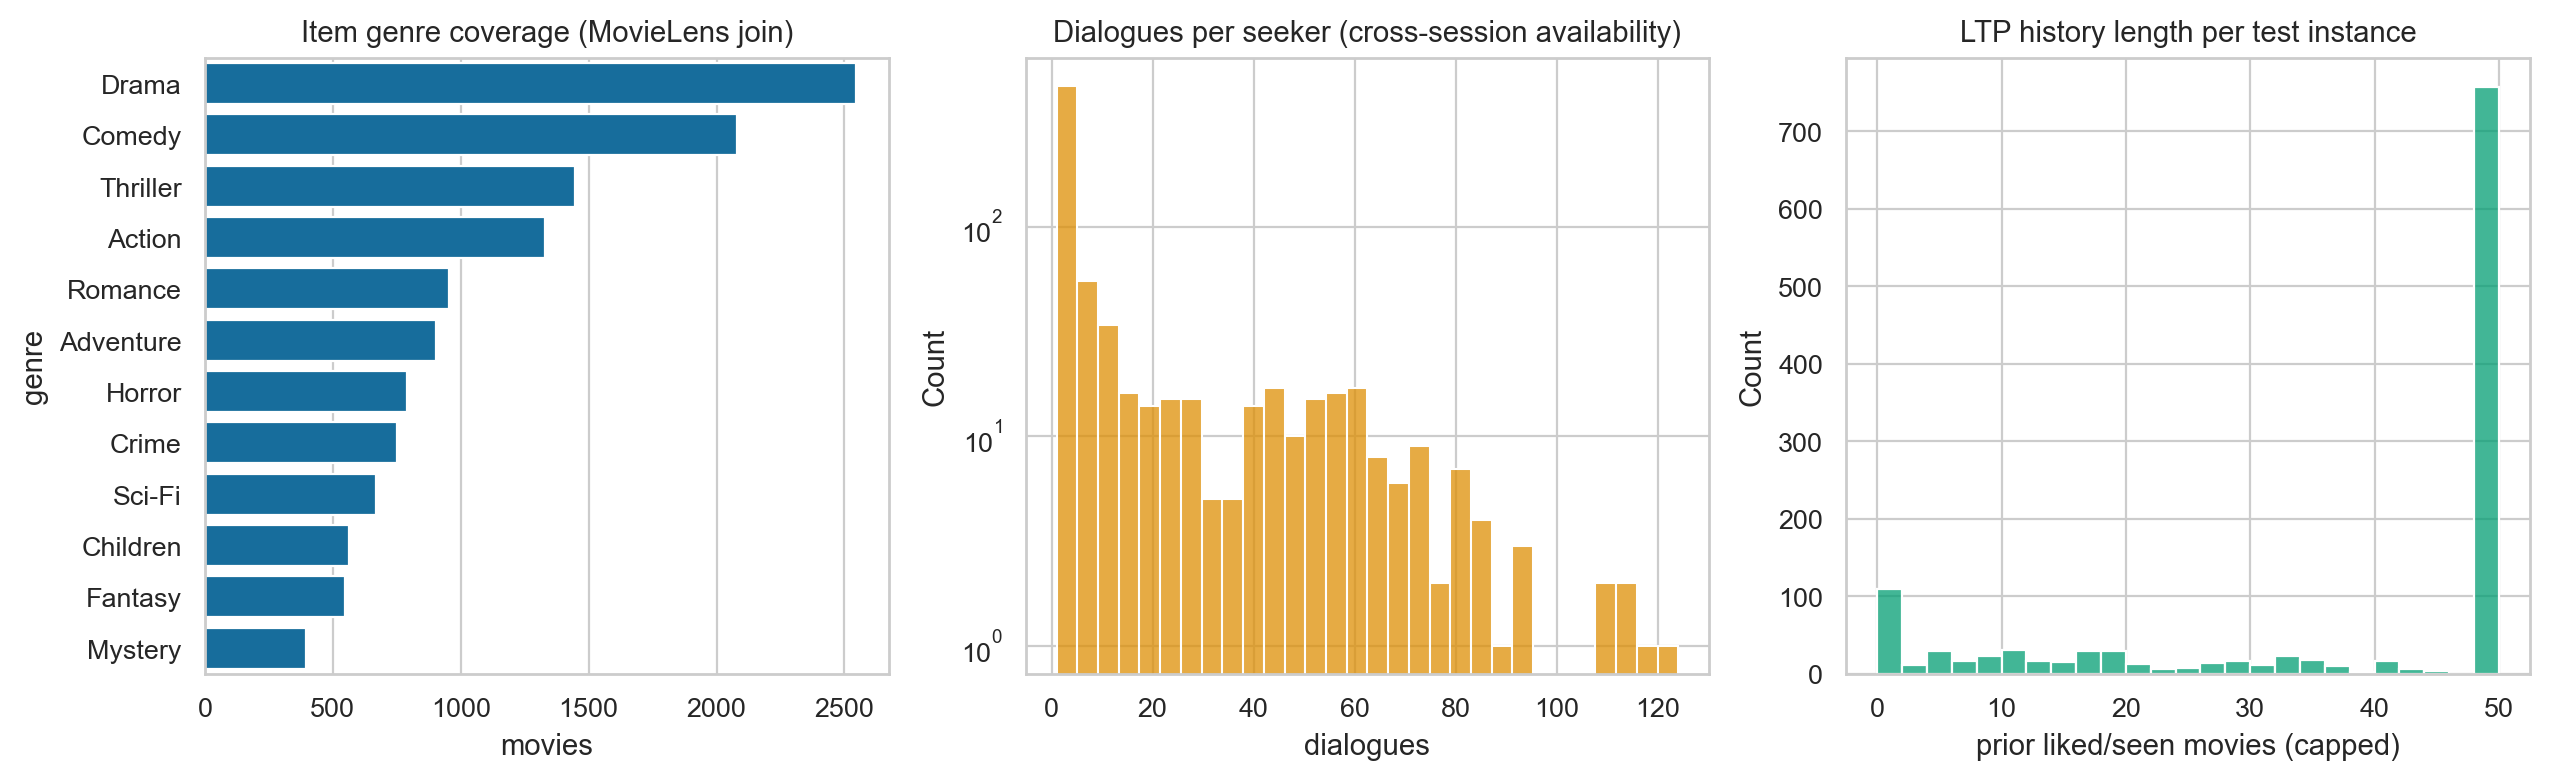

**fig02_label_distribution**

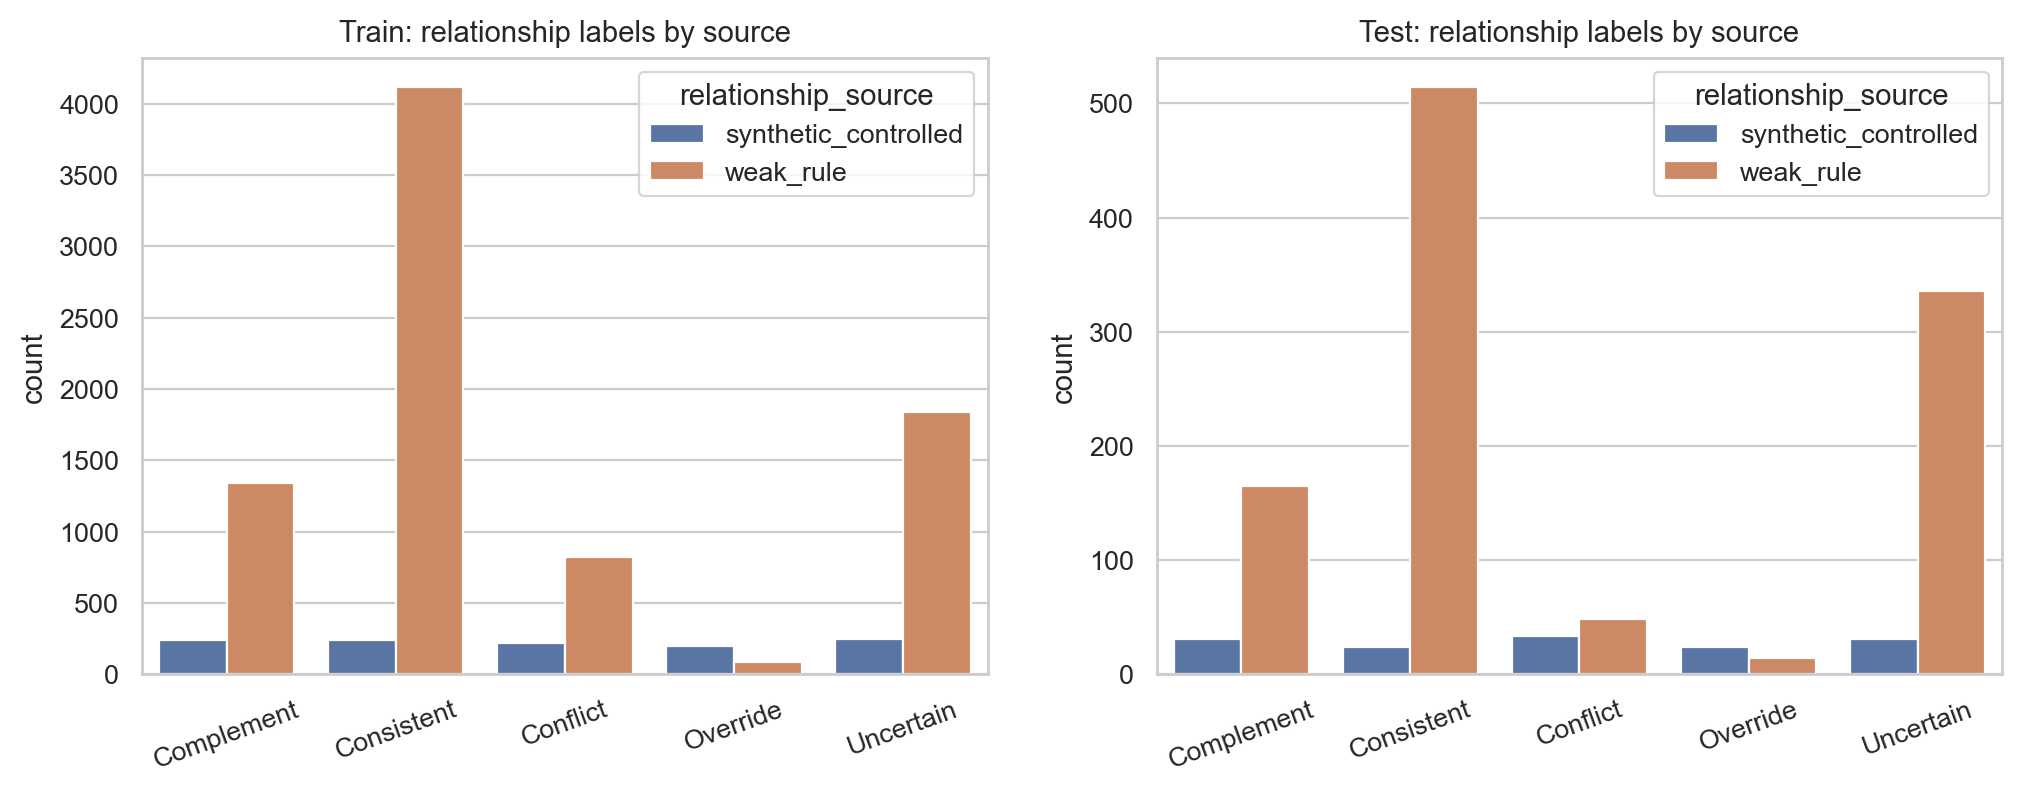

**fig03_overall_natural**

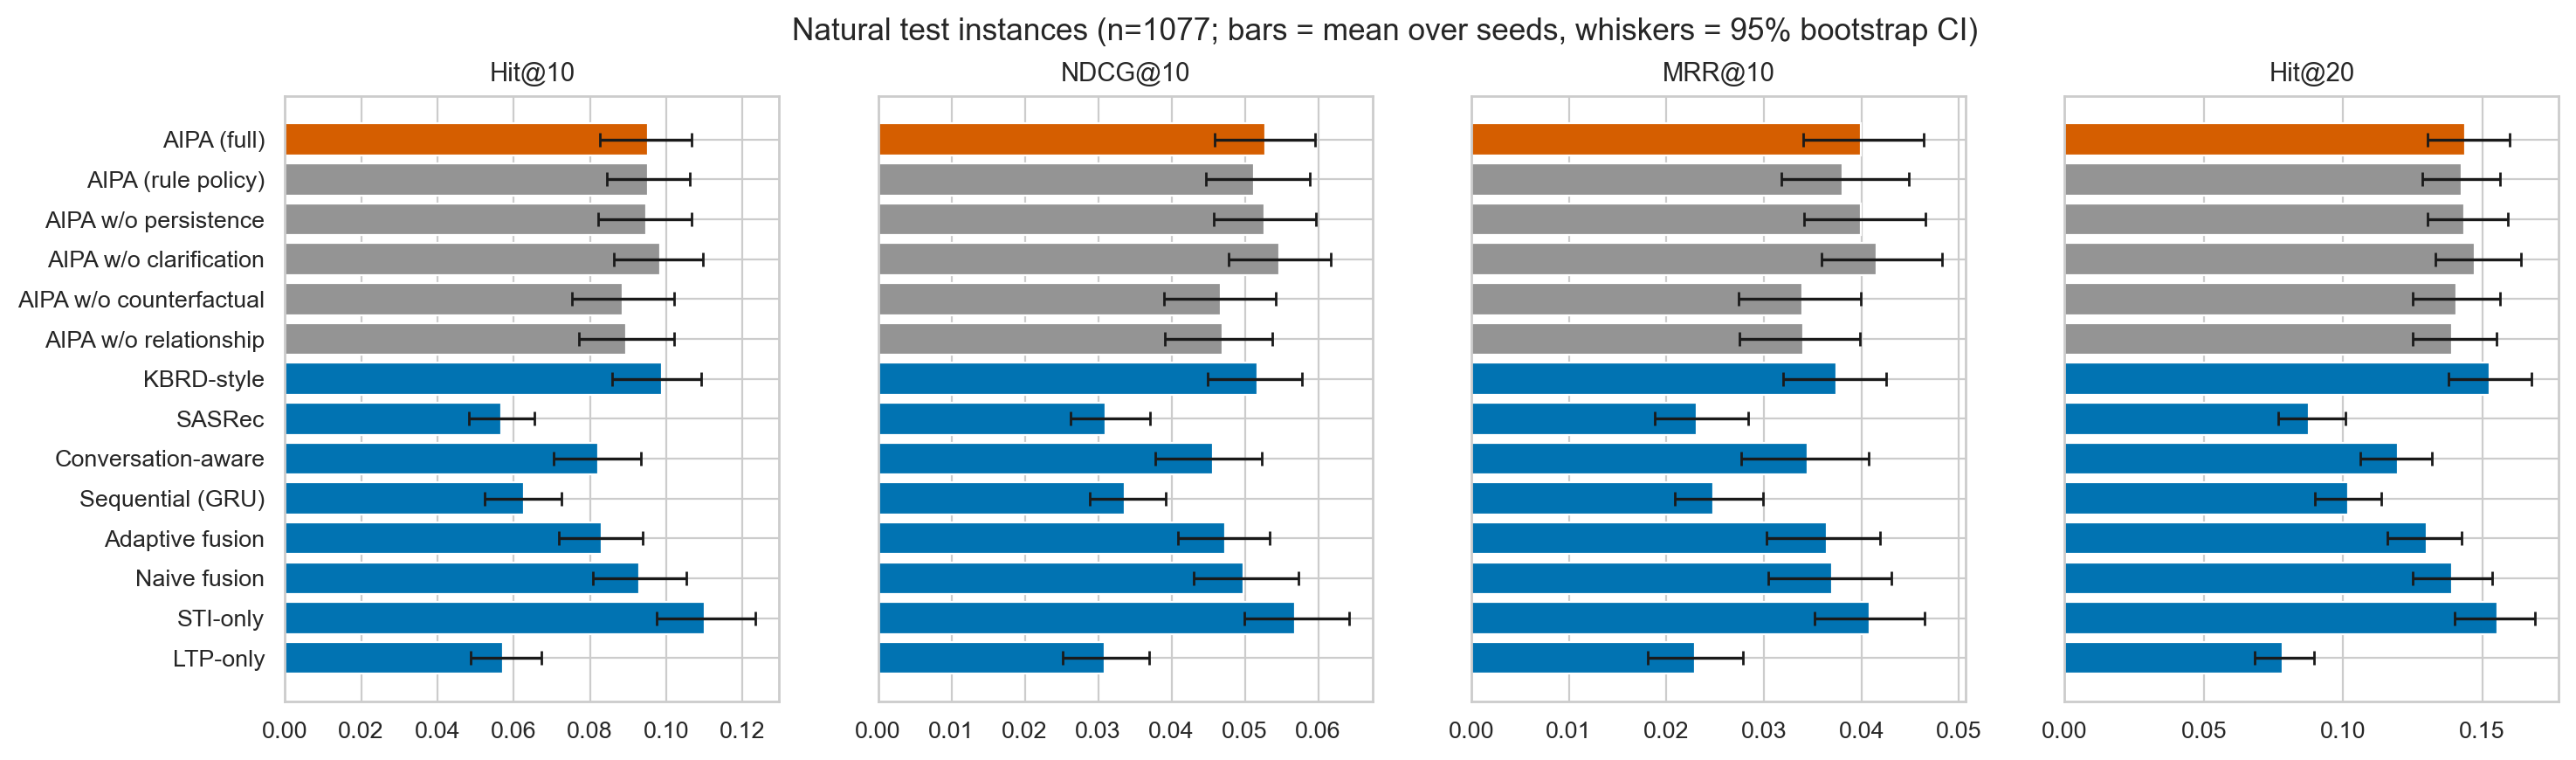

**fig03_overall_synthetic**

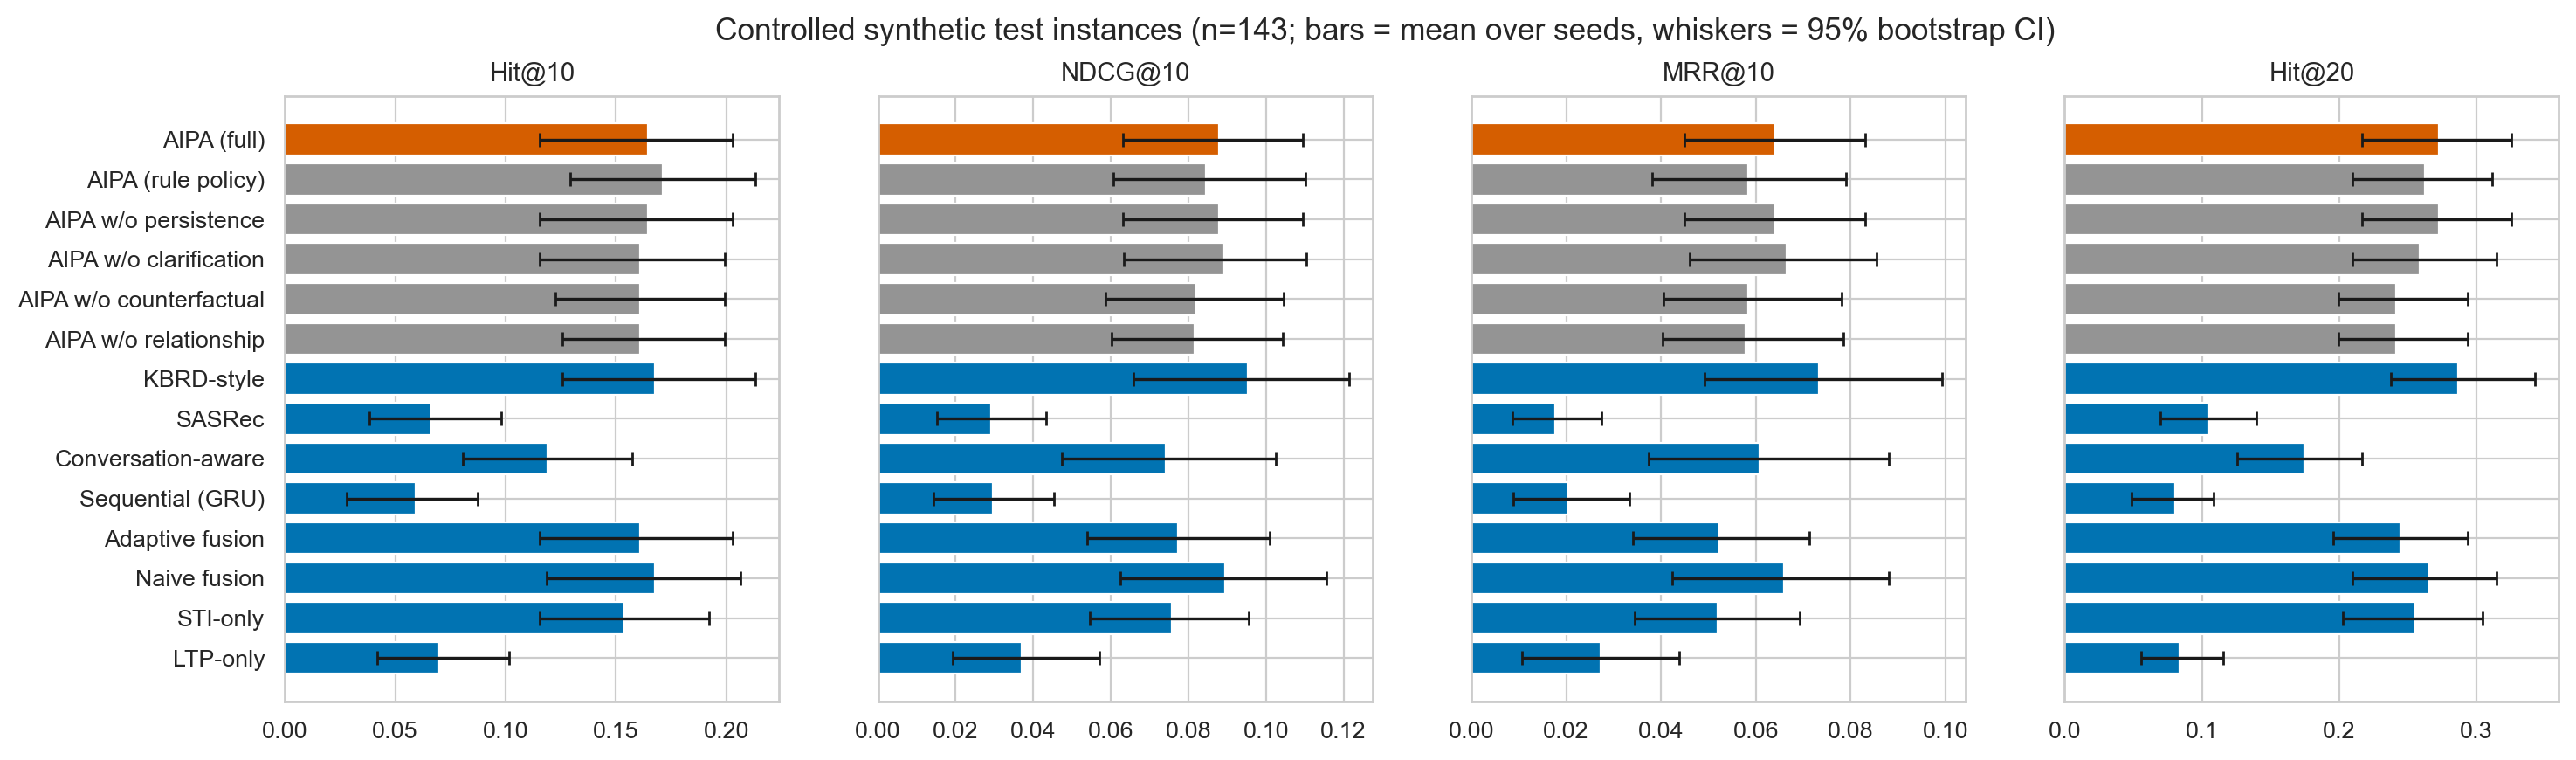

**fig03_conflict_natural_strict**

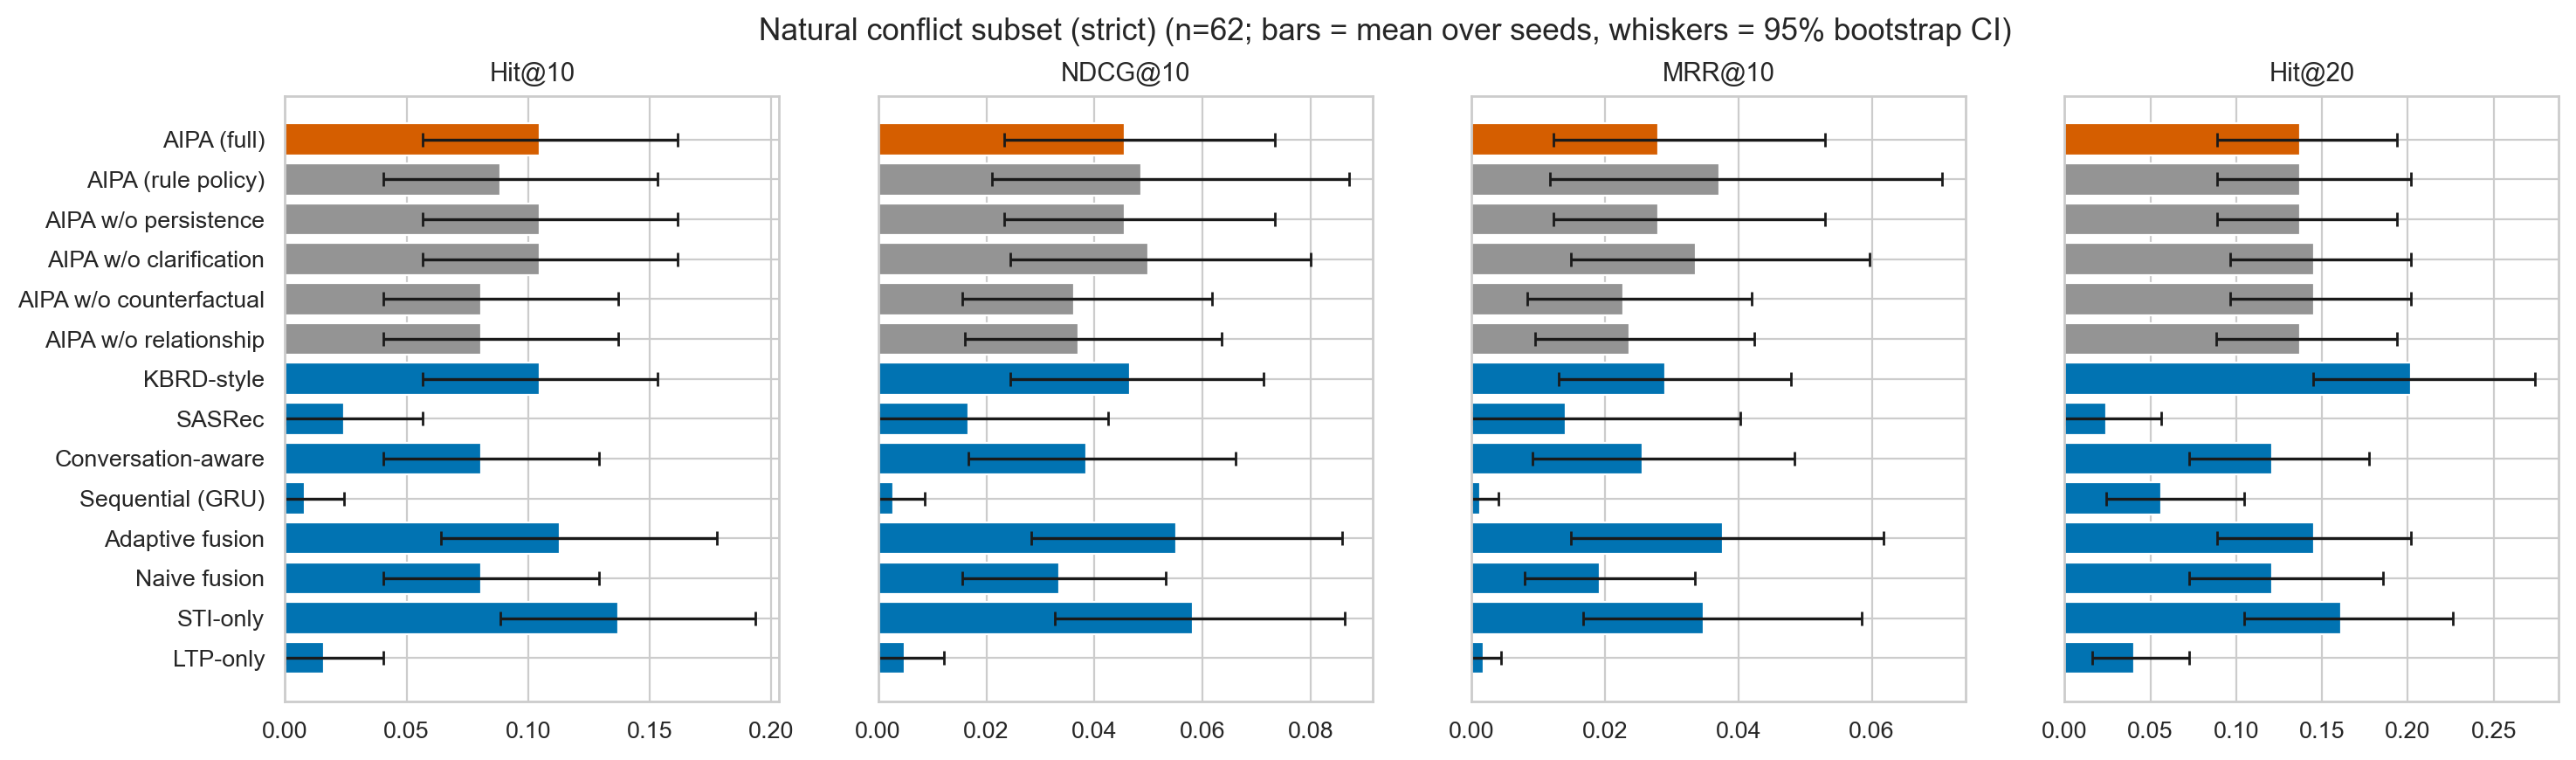

**fig03_conflict_natural_broad**

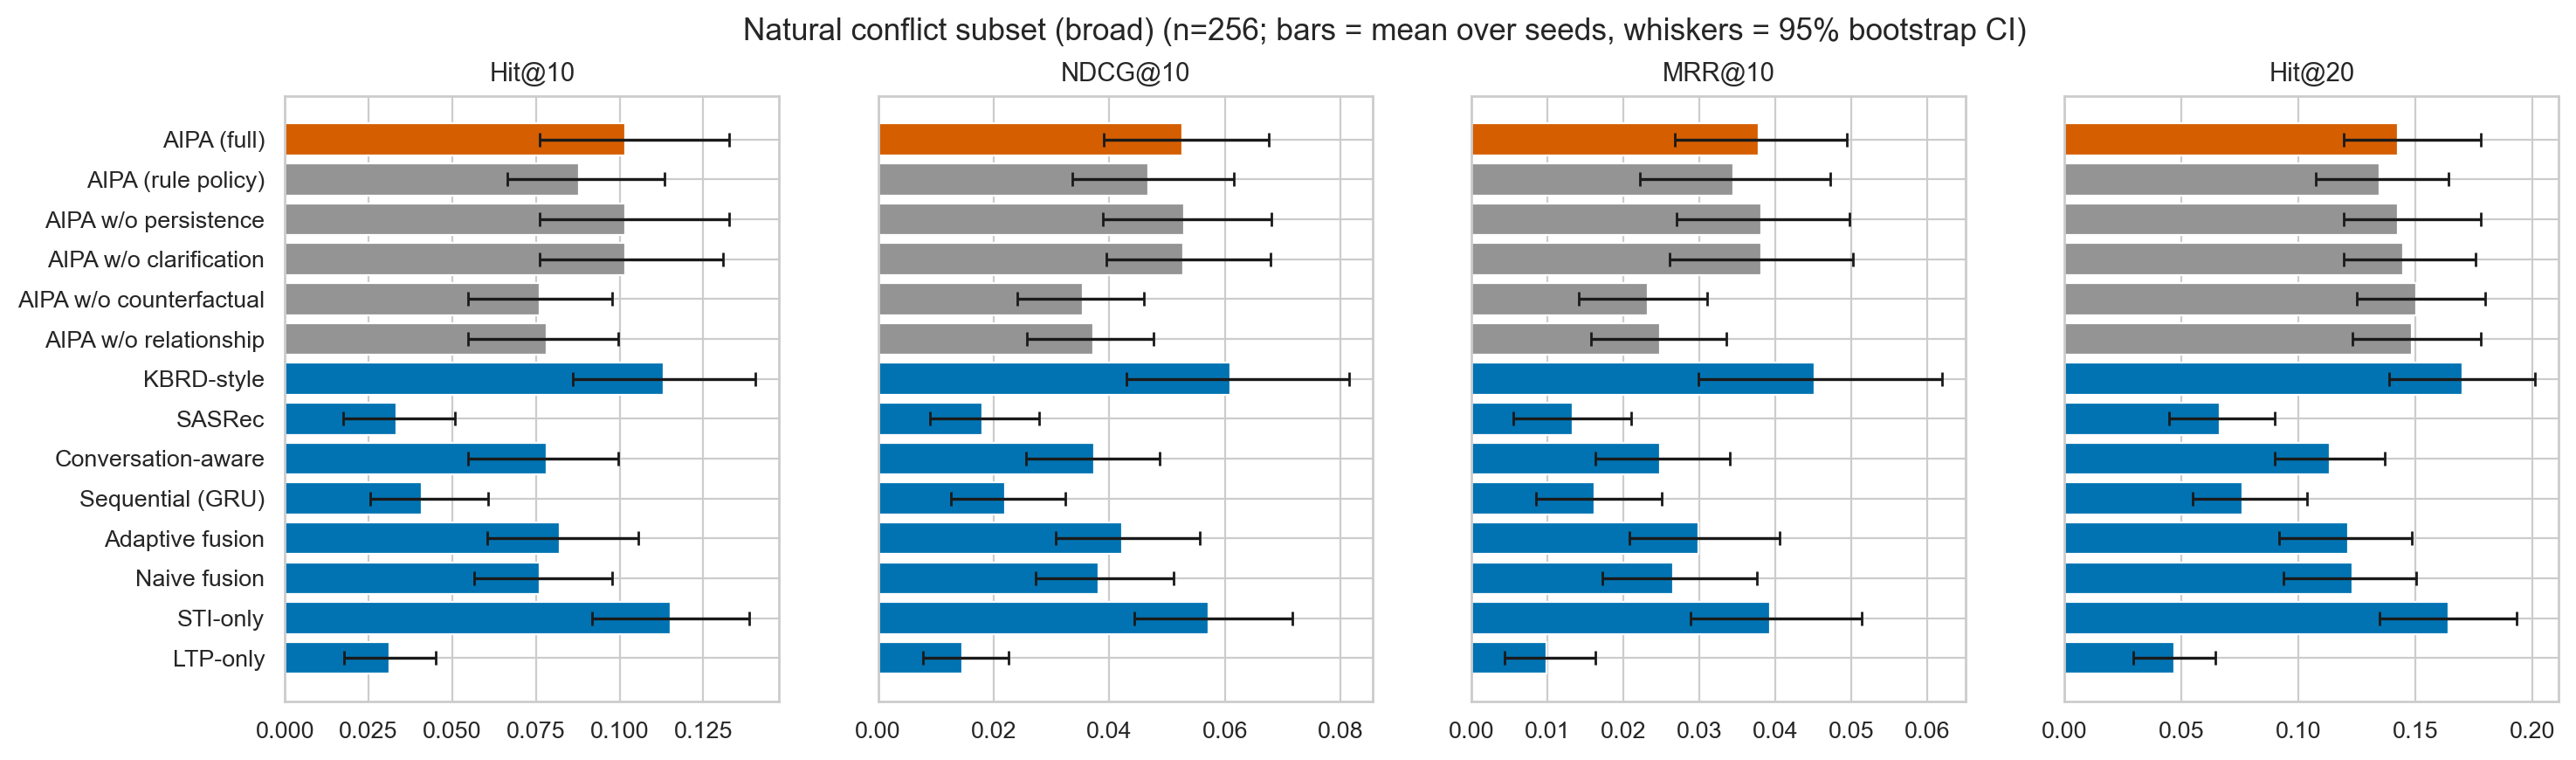

**fig03_conflict_synthetic**

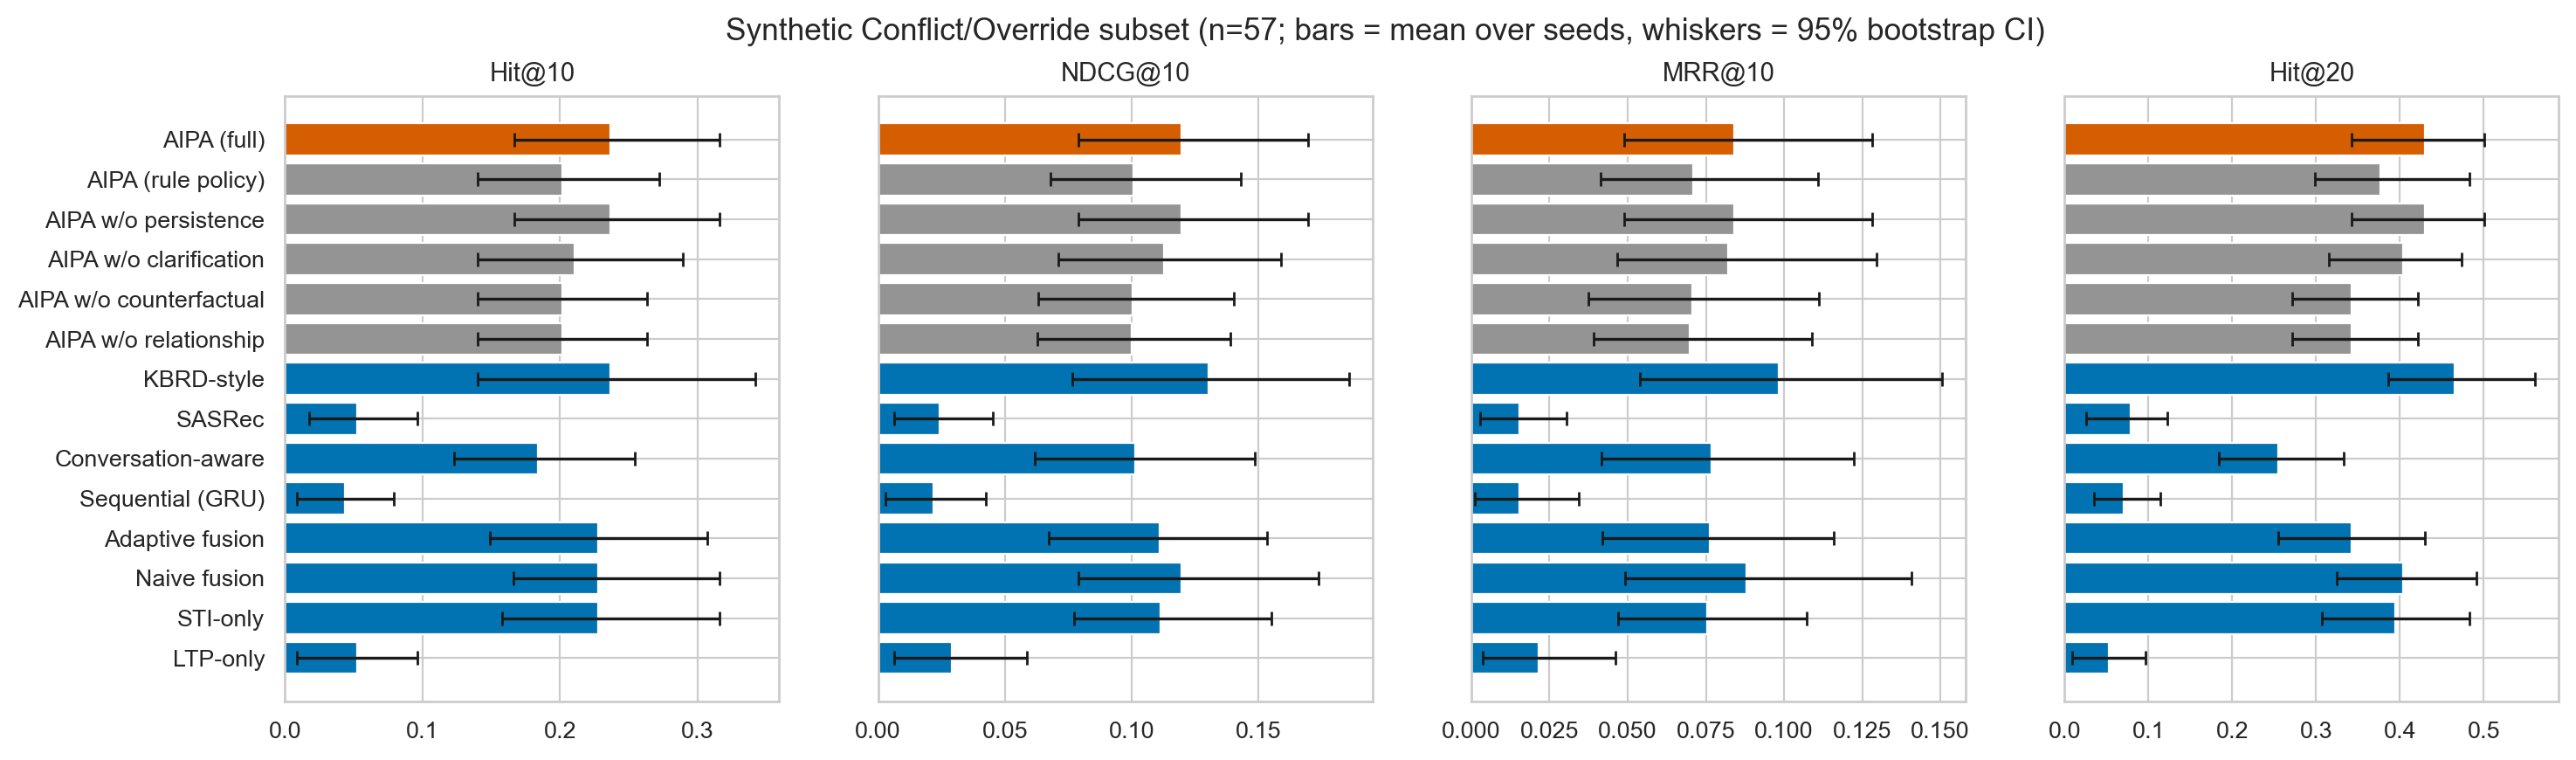

**fig04_conflict_vs_nonconflict**

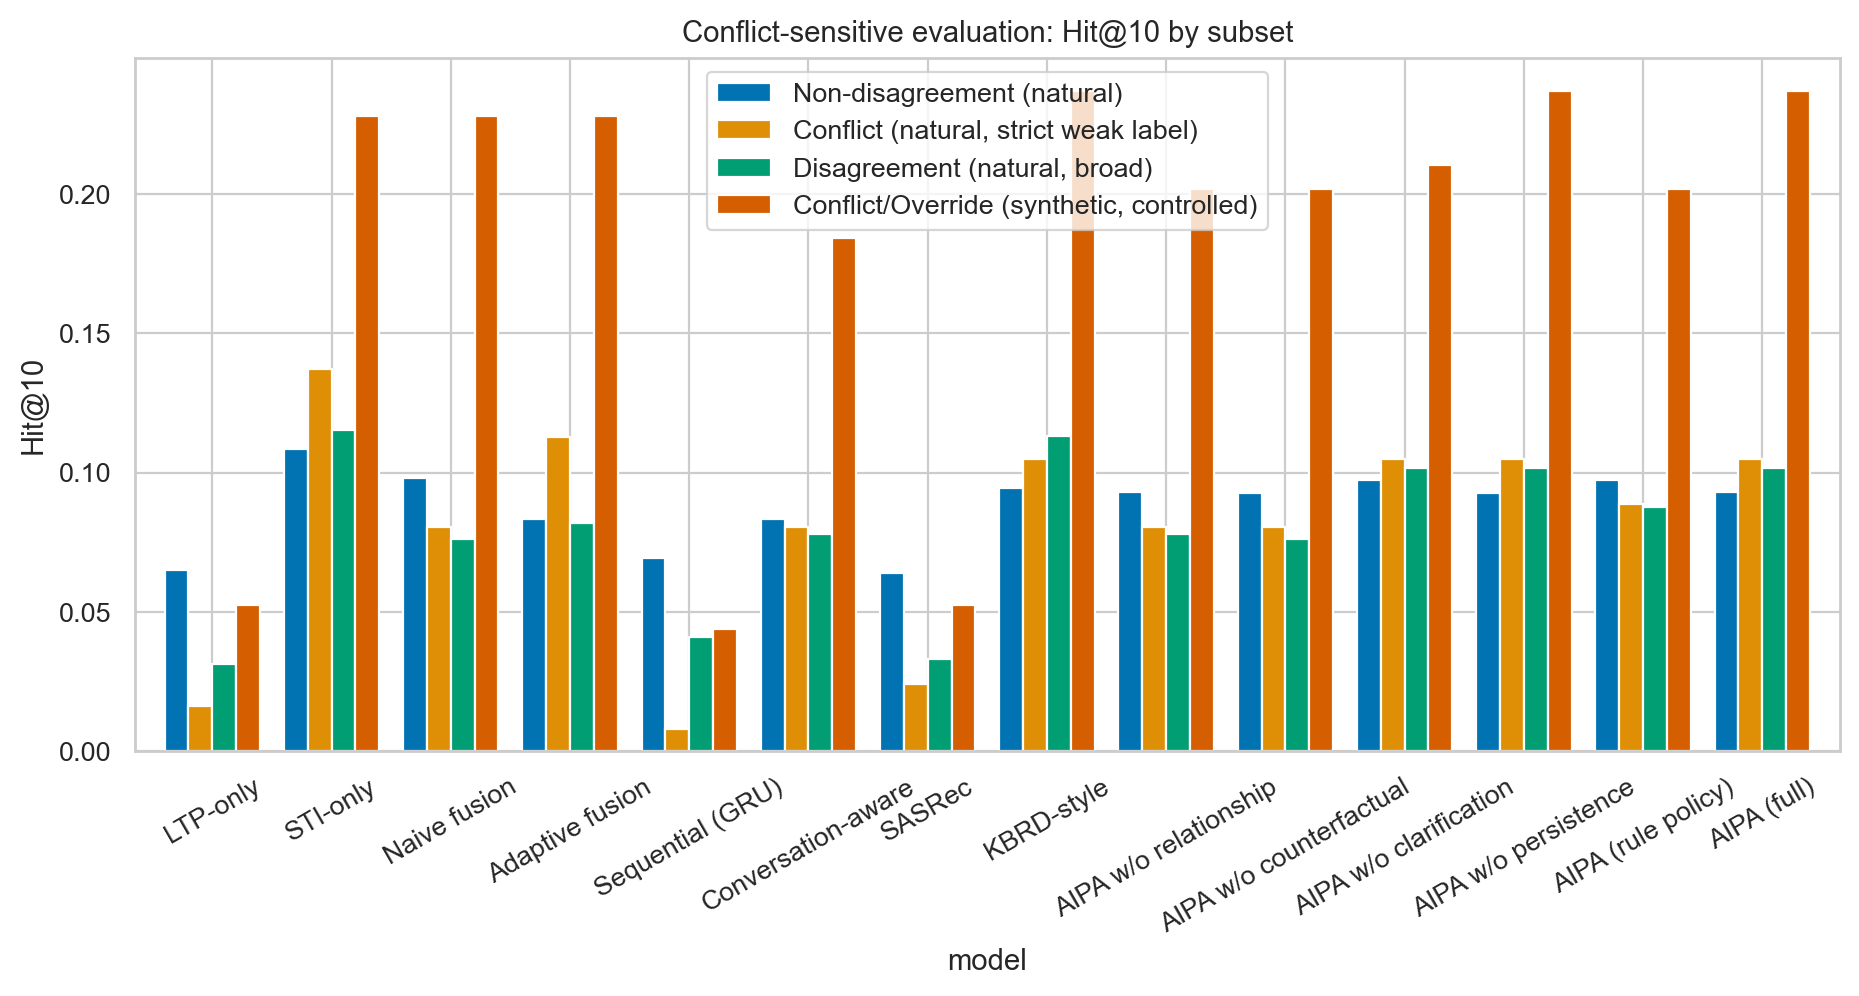

**fig05_relationship_subsets**

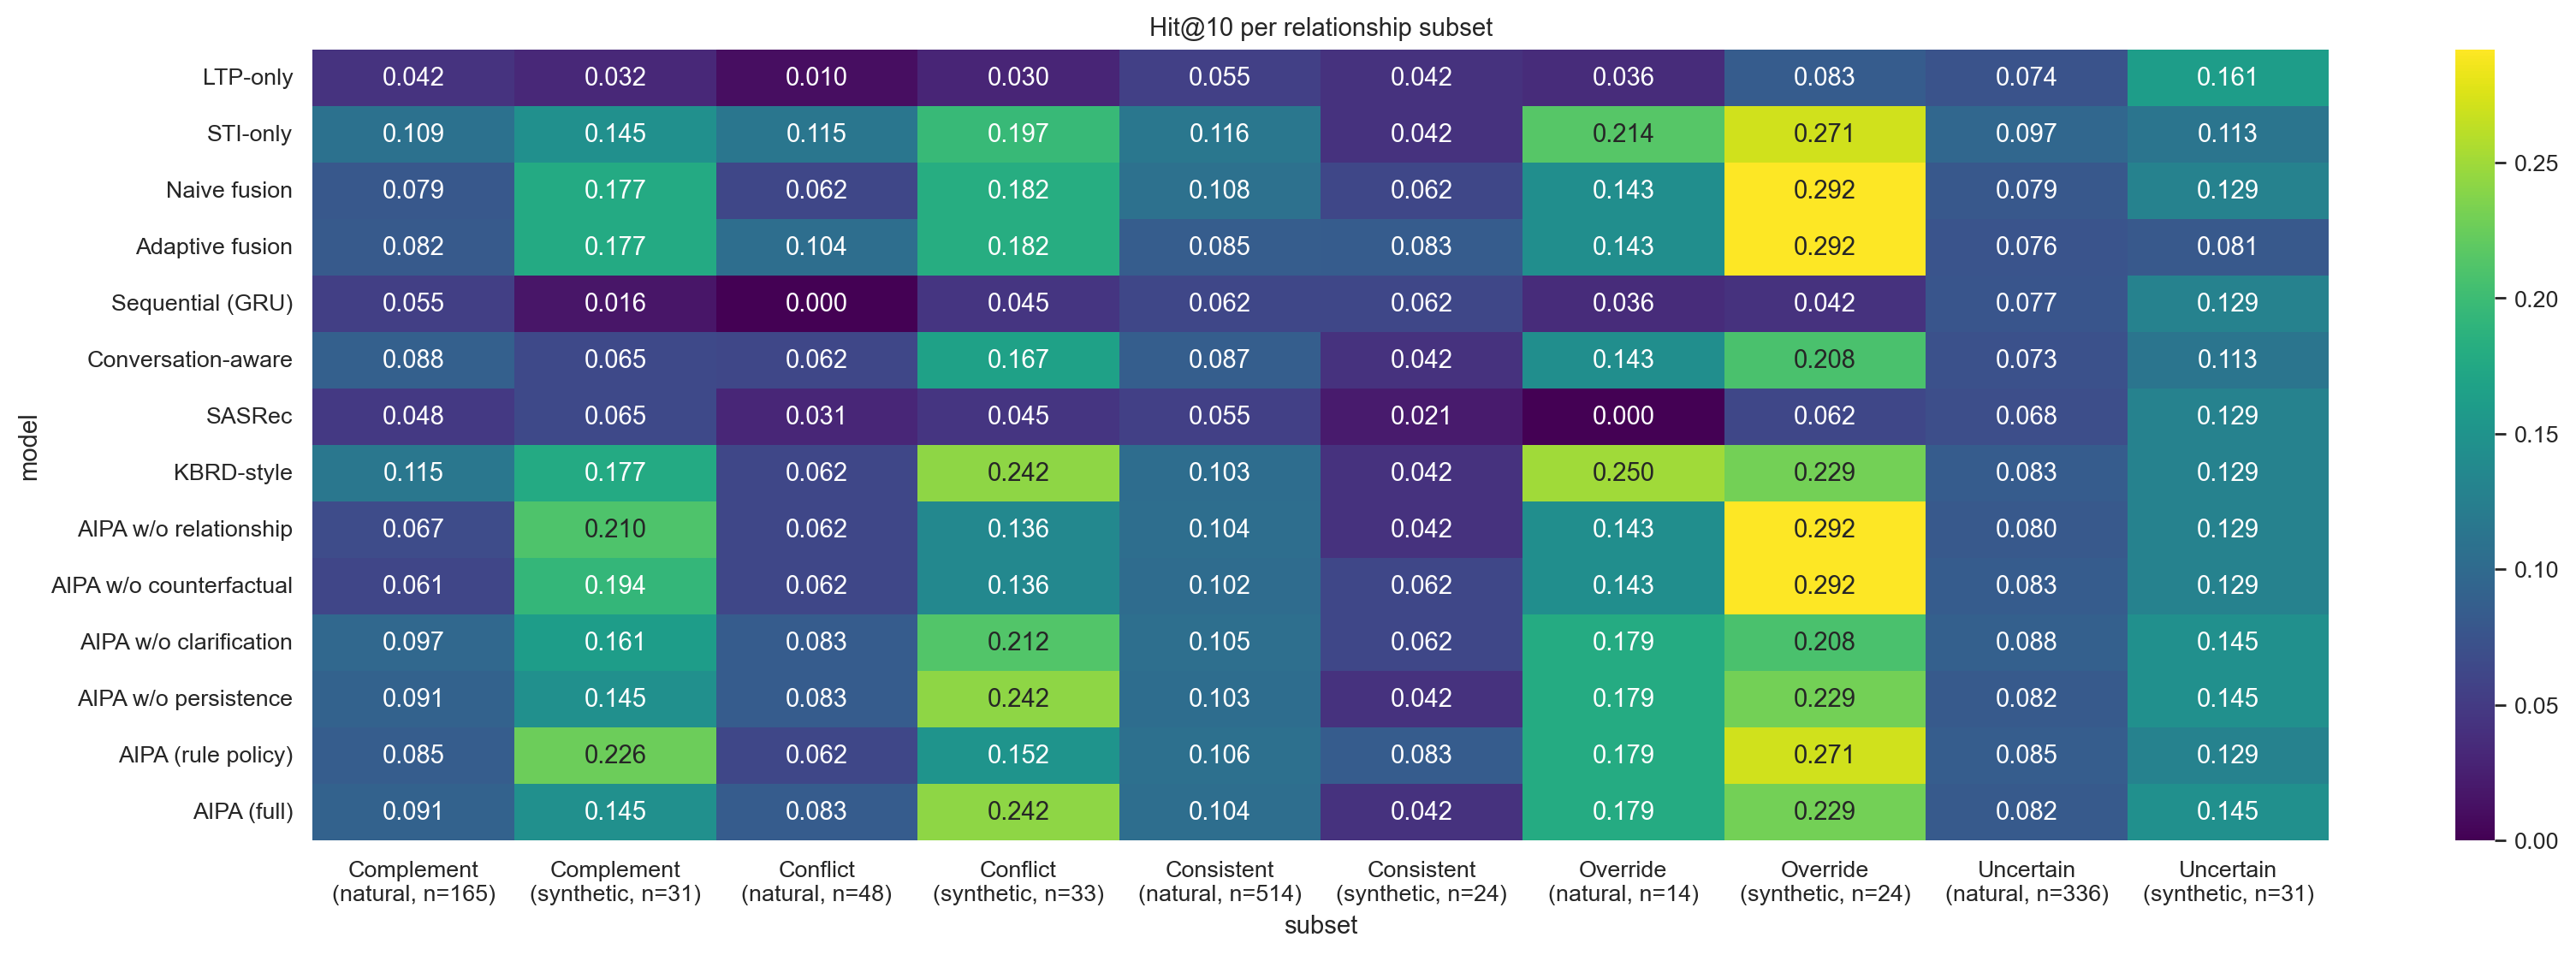

**fig06_relationship_confusion**

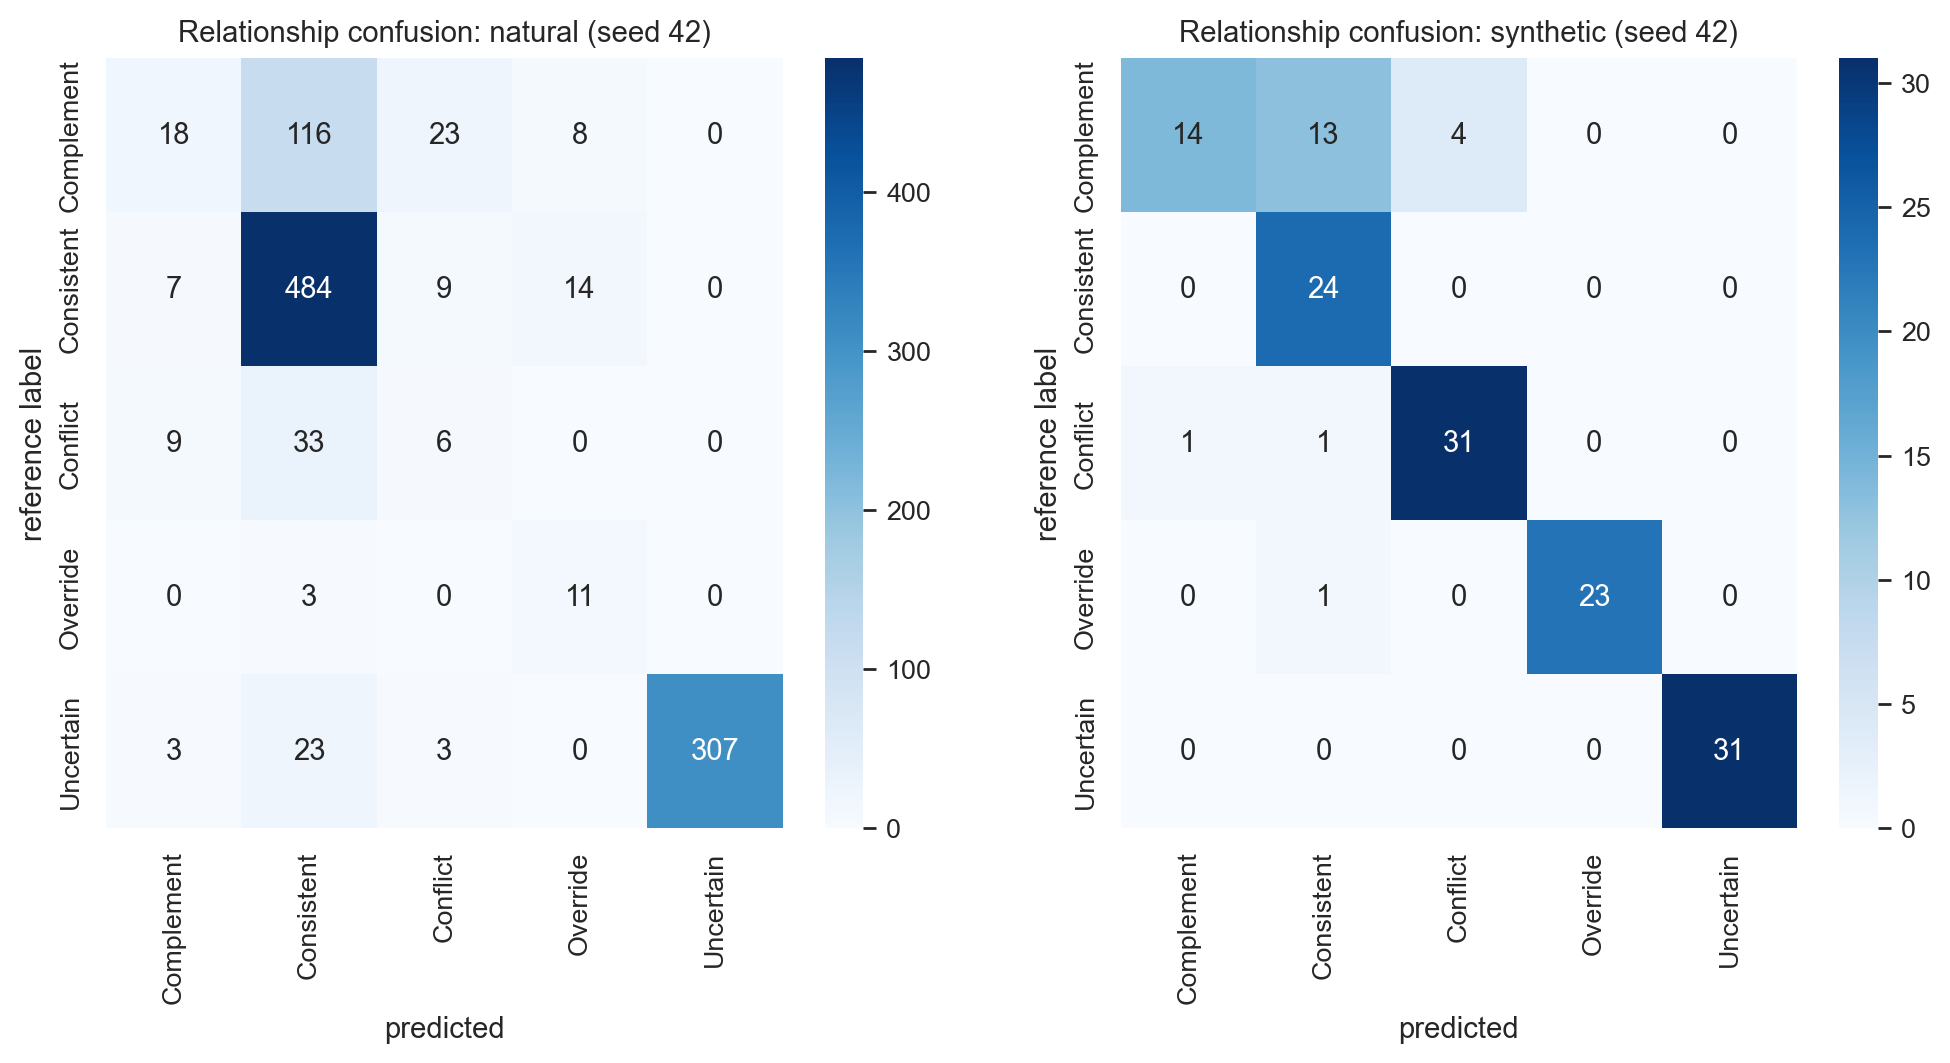

**fig07_actions_by_relationship**

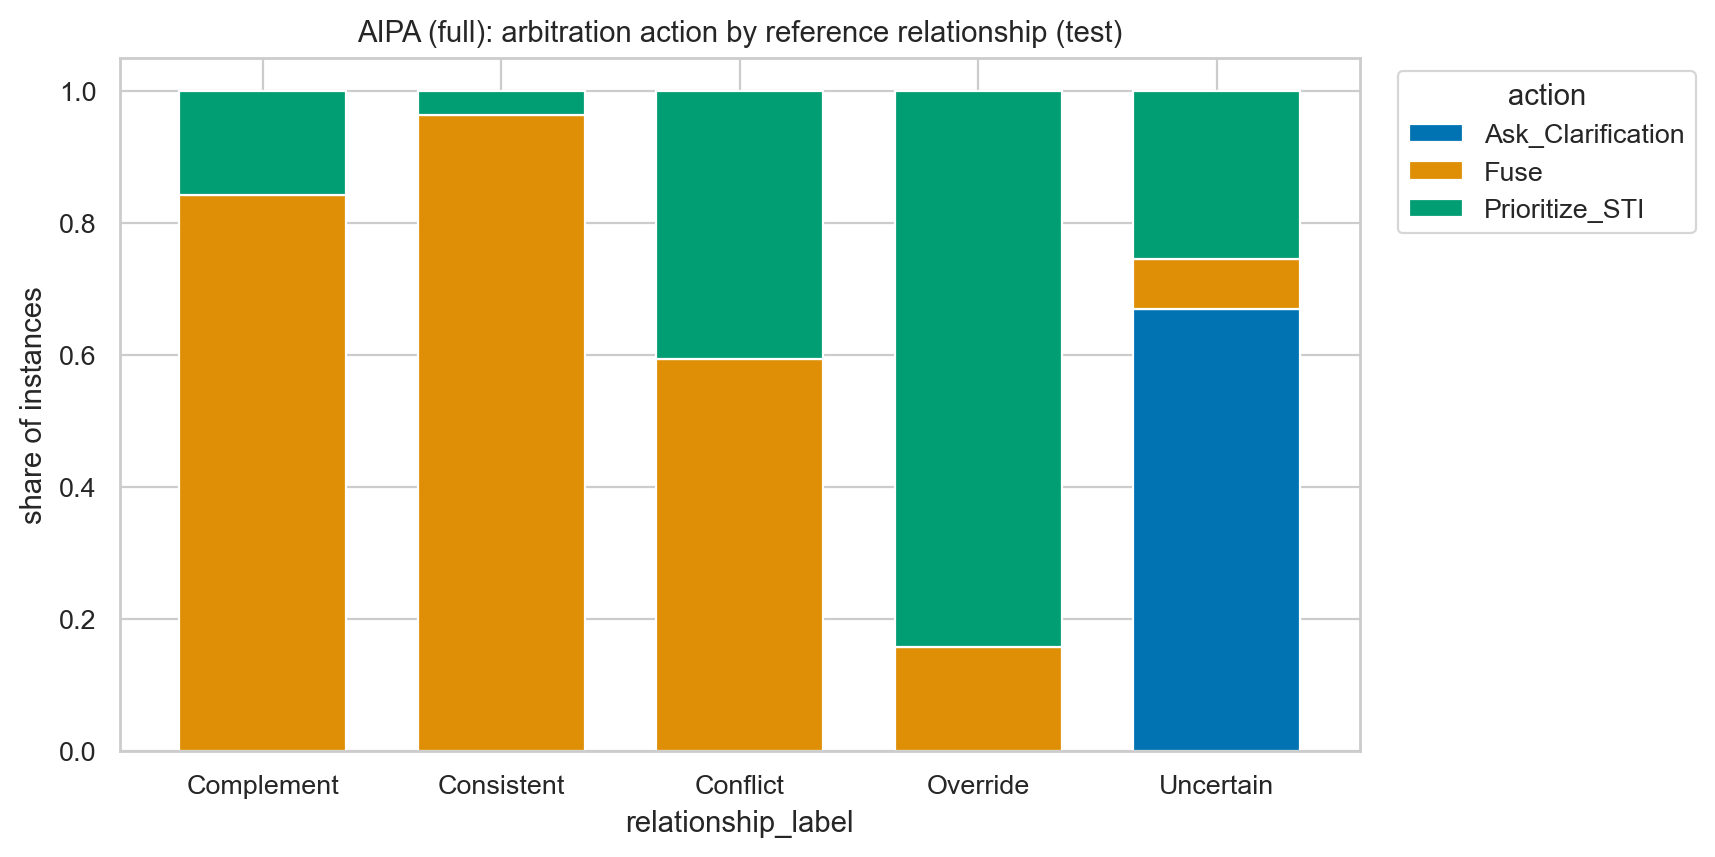

**fig08_counterfactual**

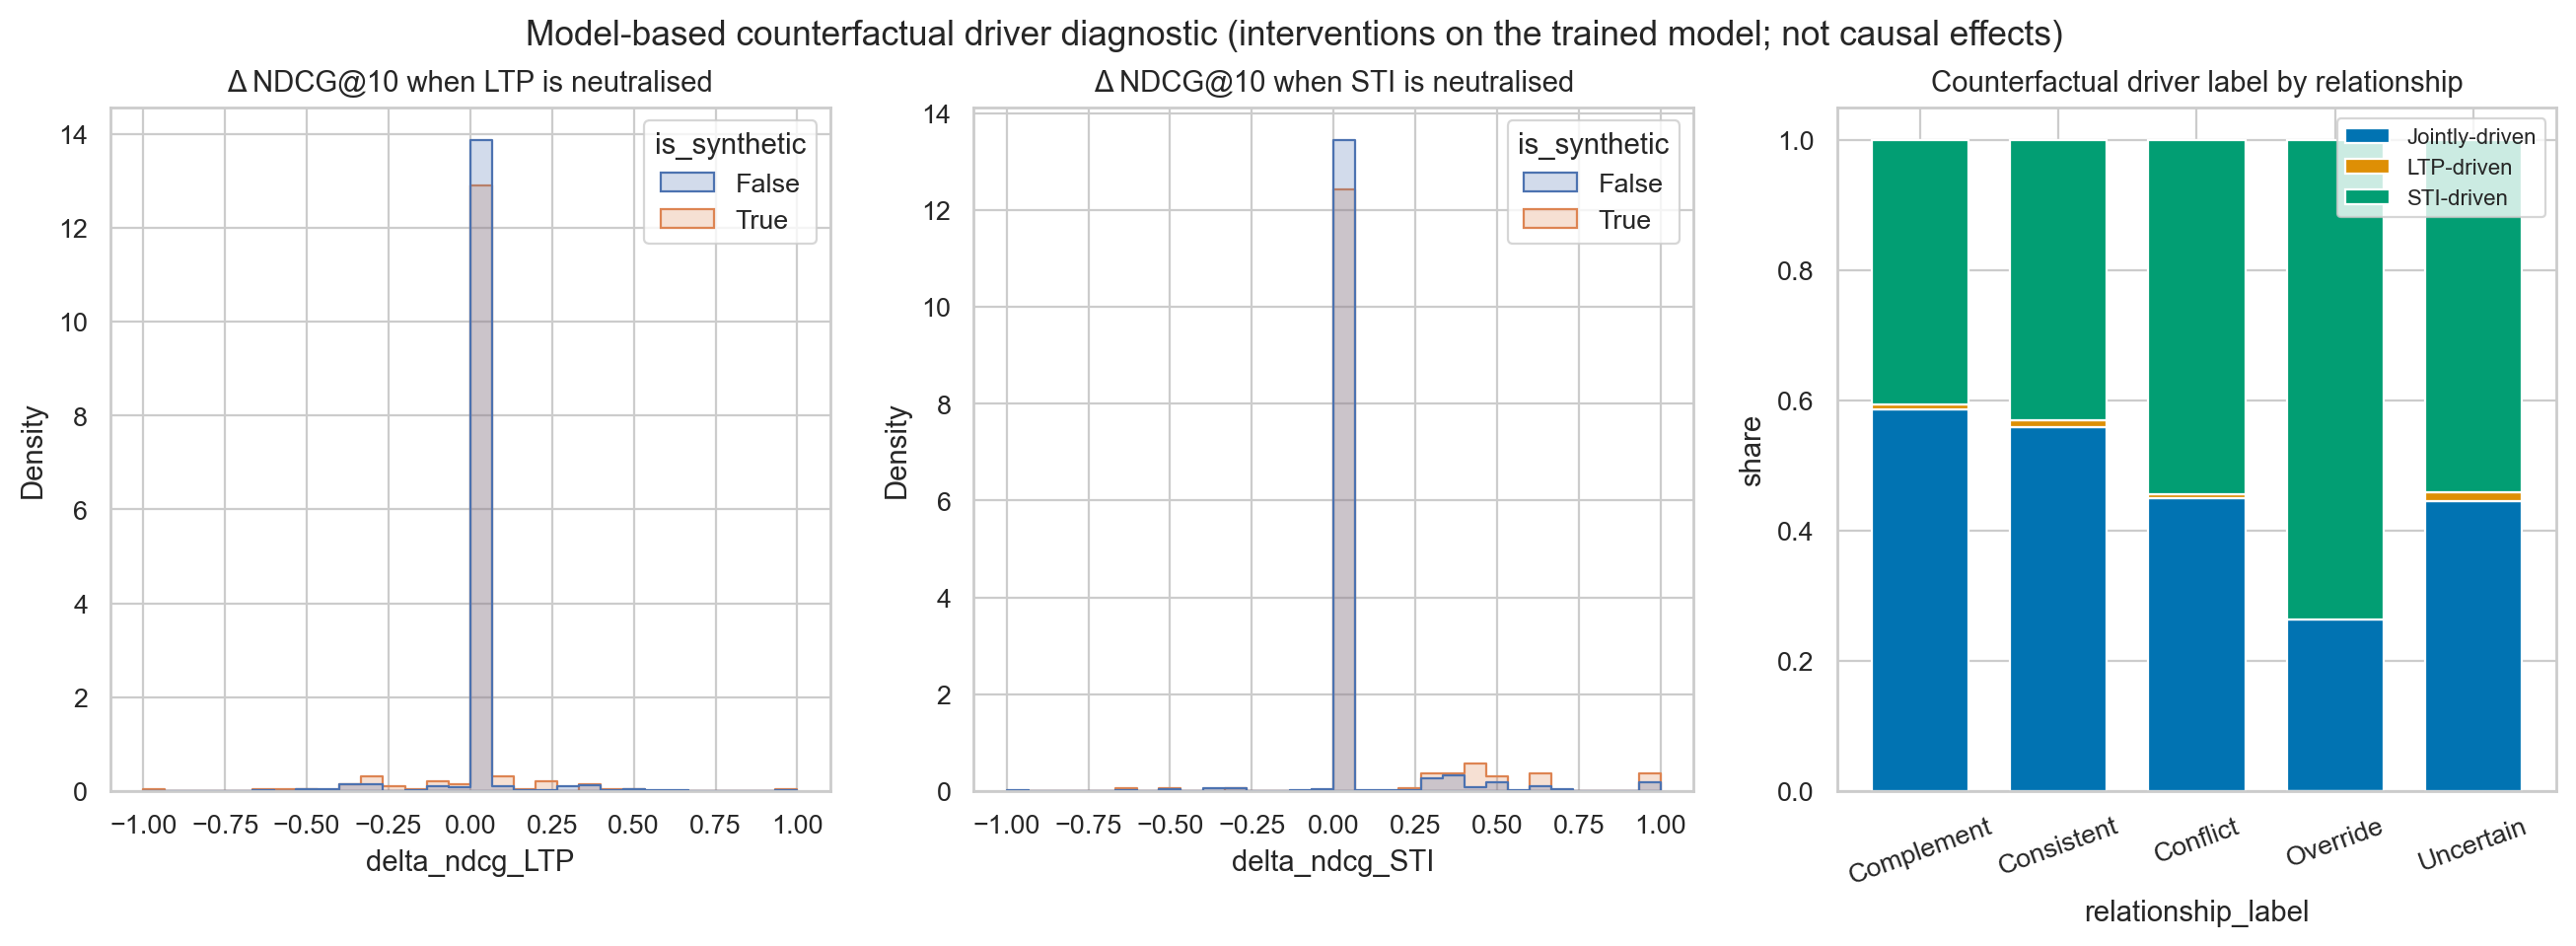

**fig09_sensitivity**

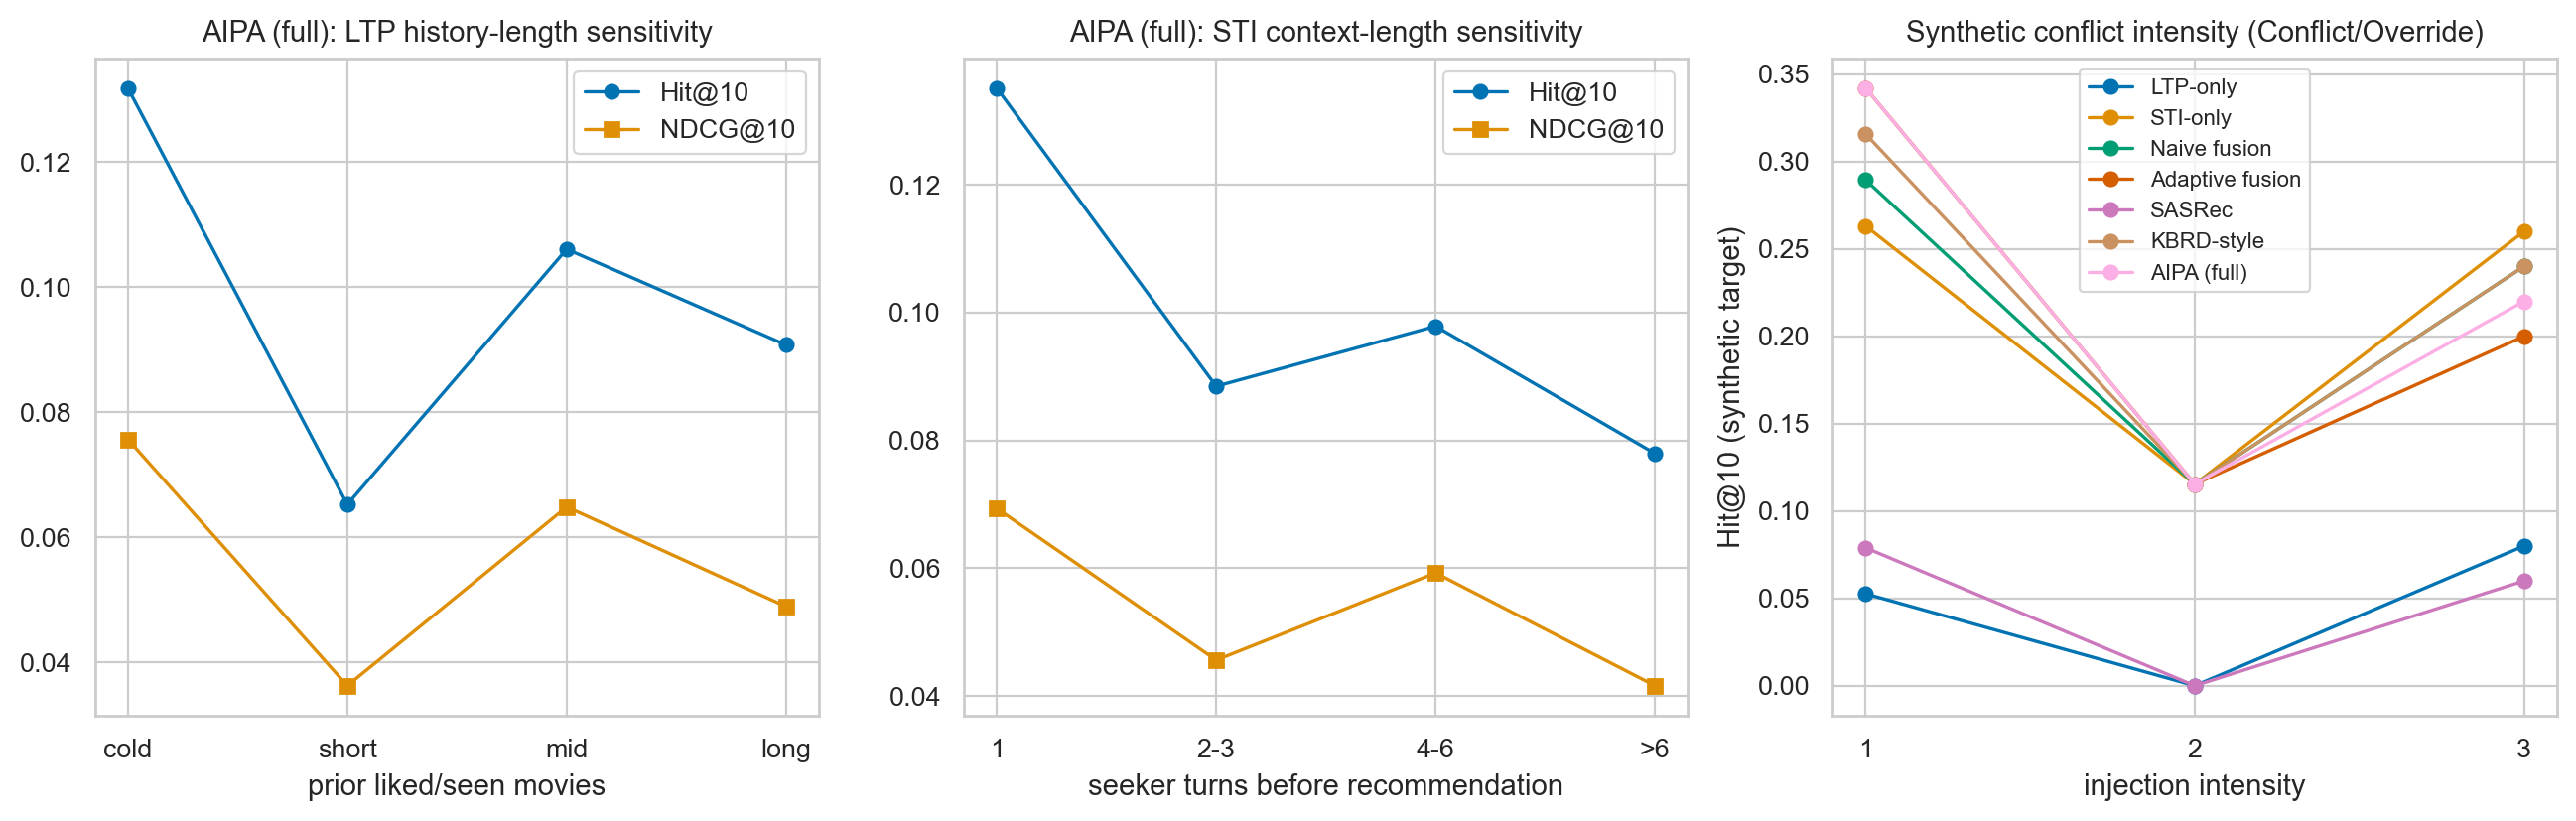

**fig09b_history_buckets**

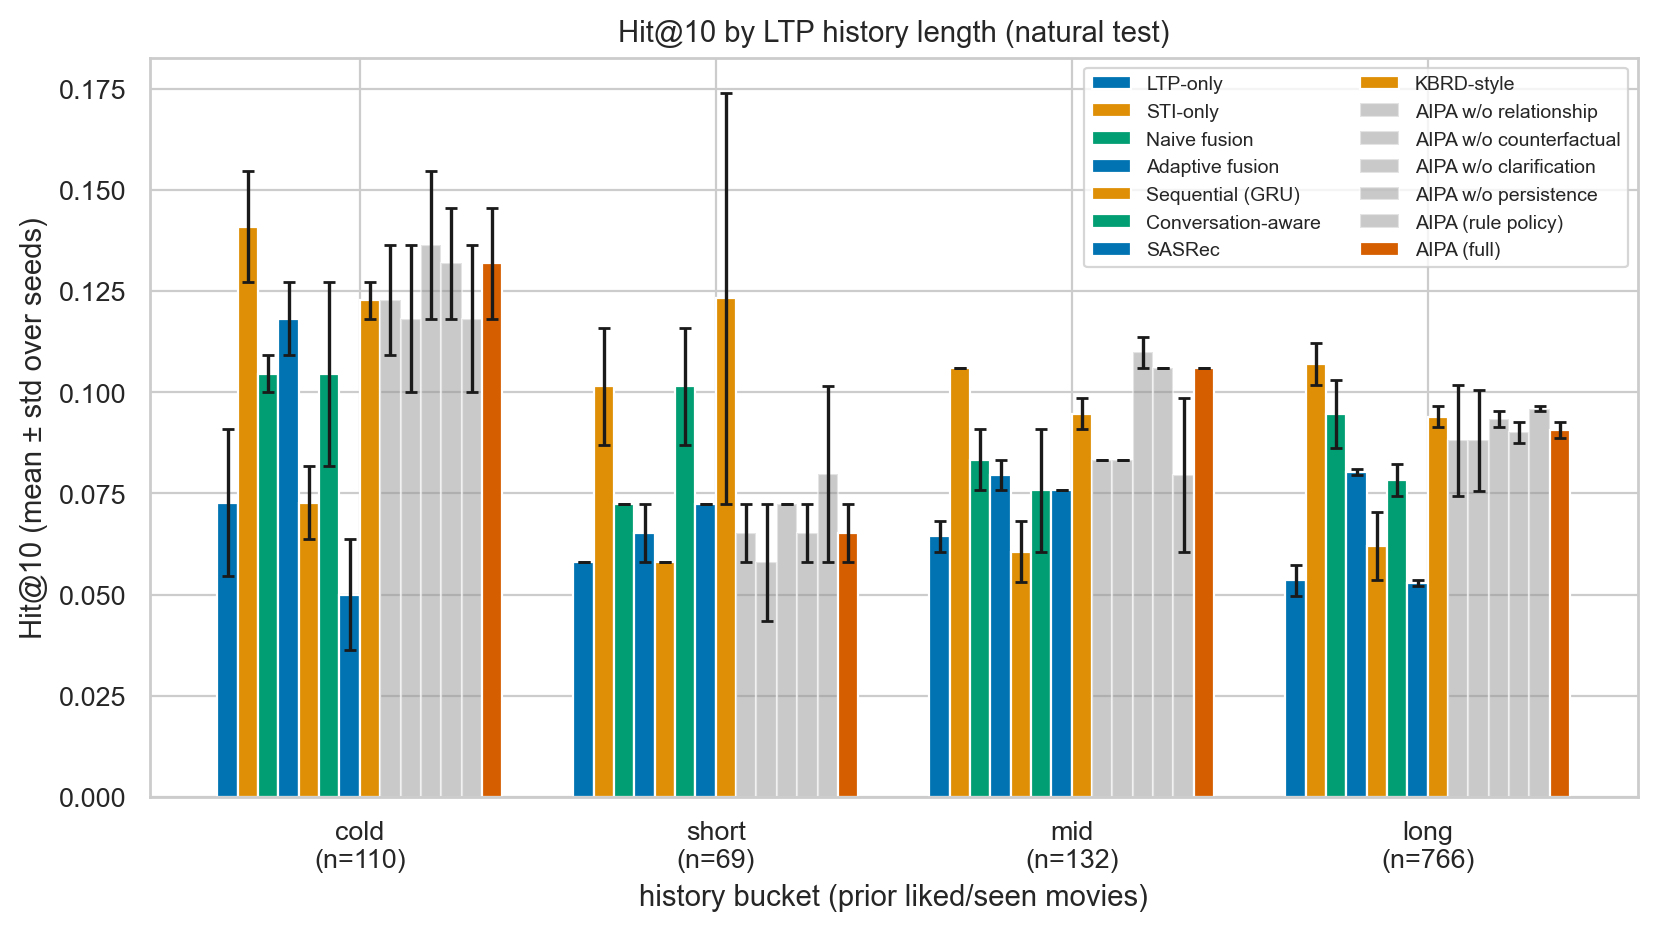

**fig09c_genre_breakdown**

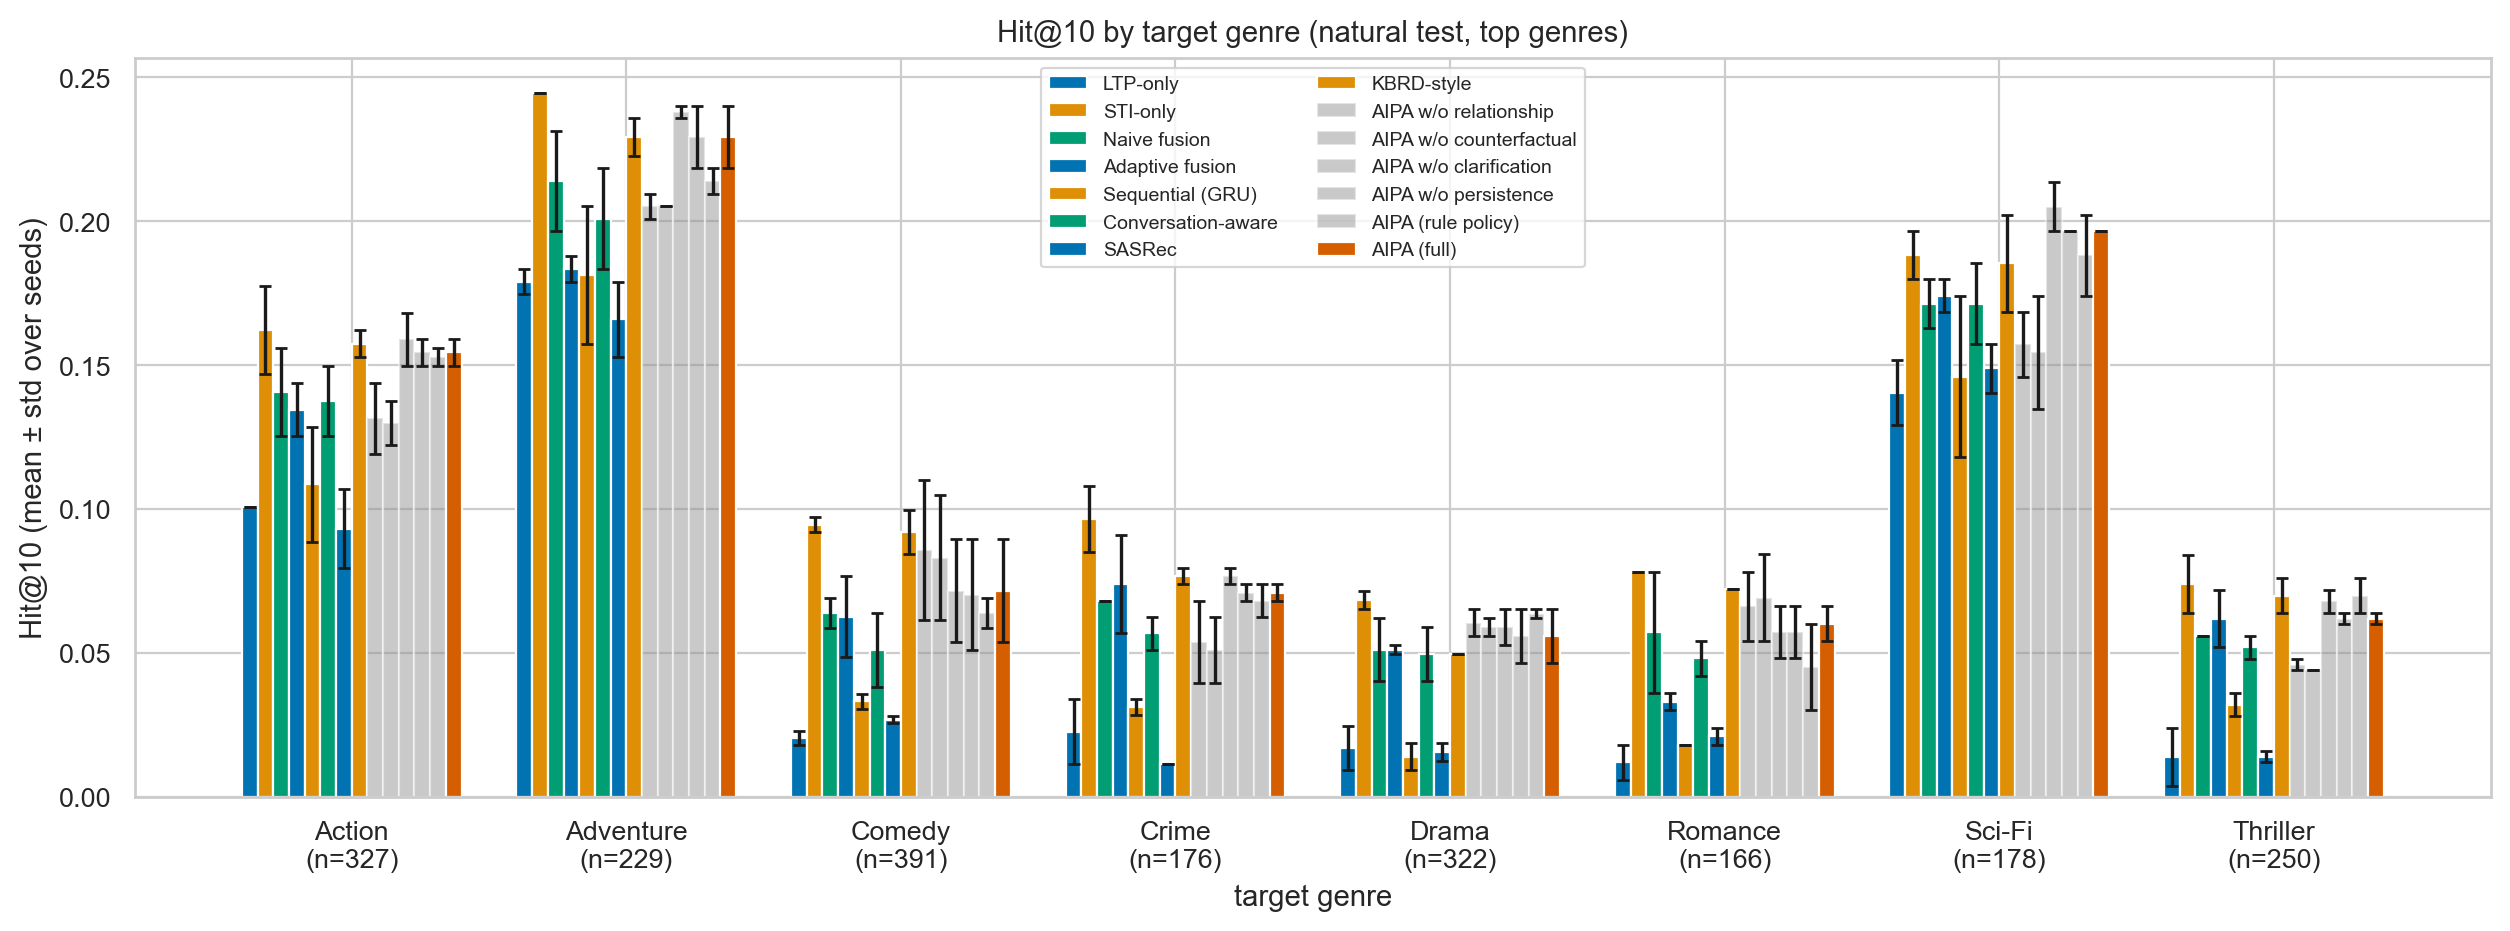

**fig10_alpha_sweep**

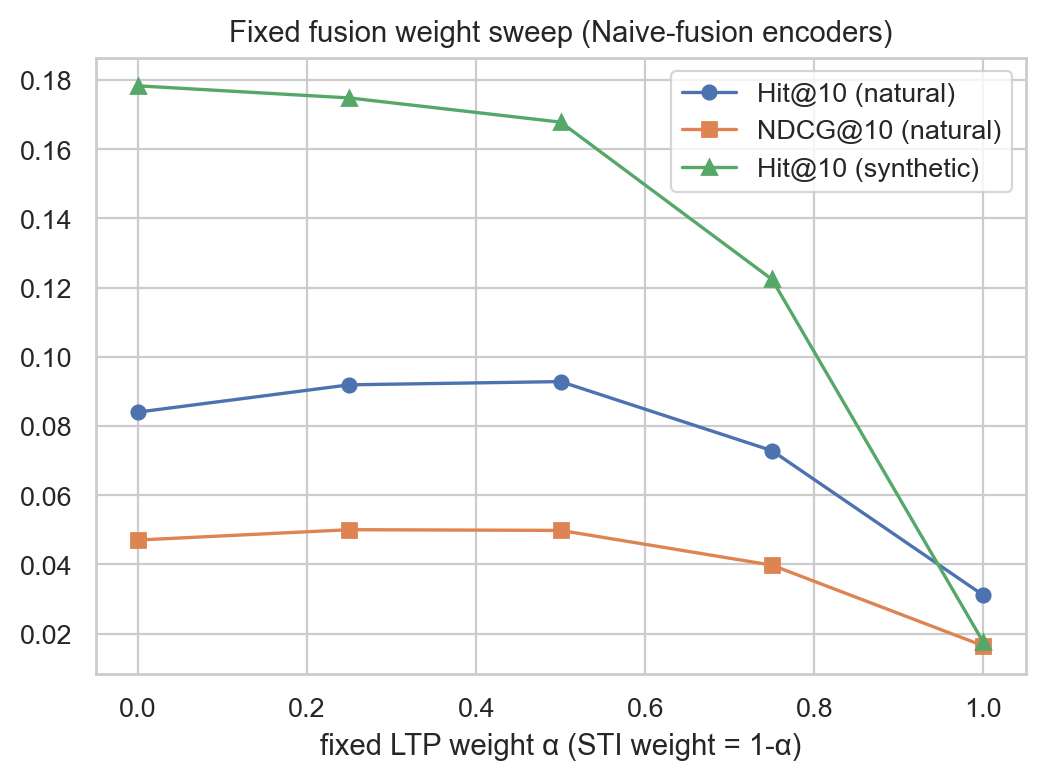

**fig11_calibration**

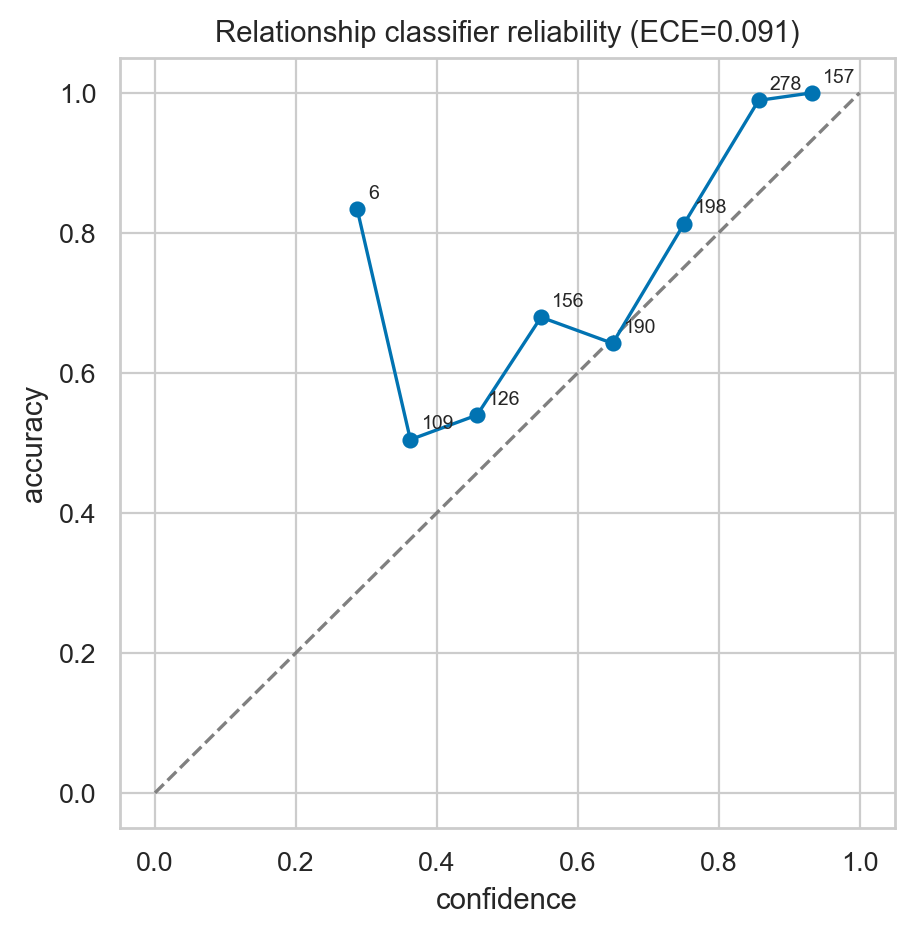

**fig12_training_curves**

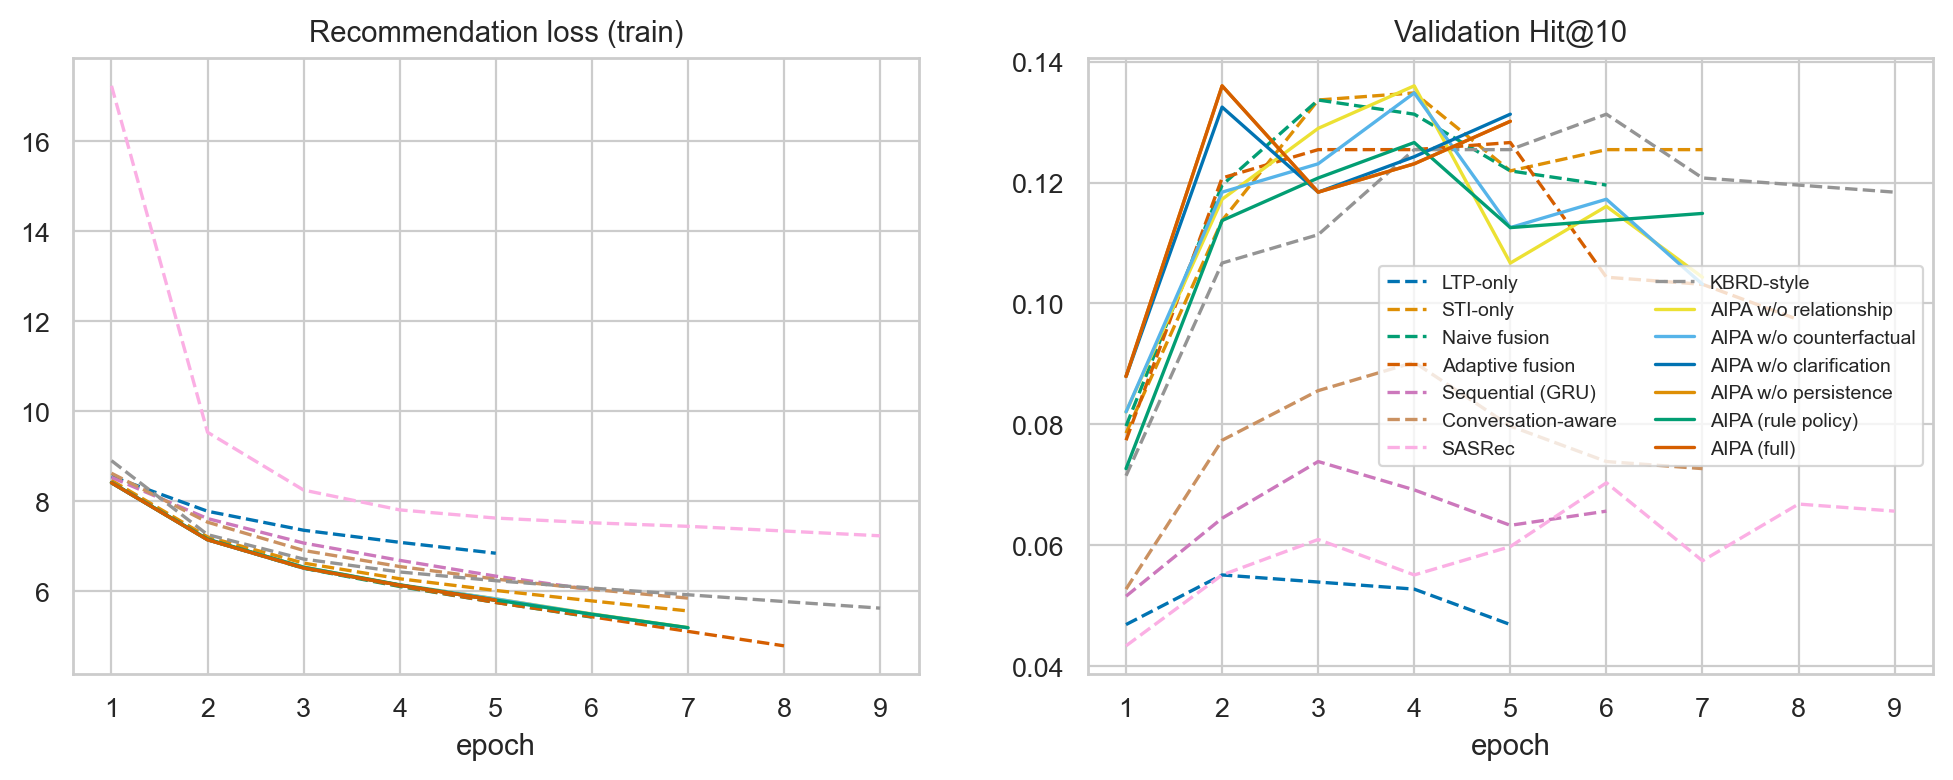

**fig13_efficiency**

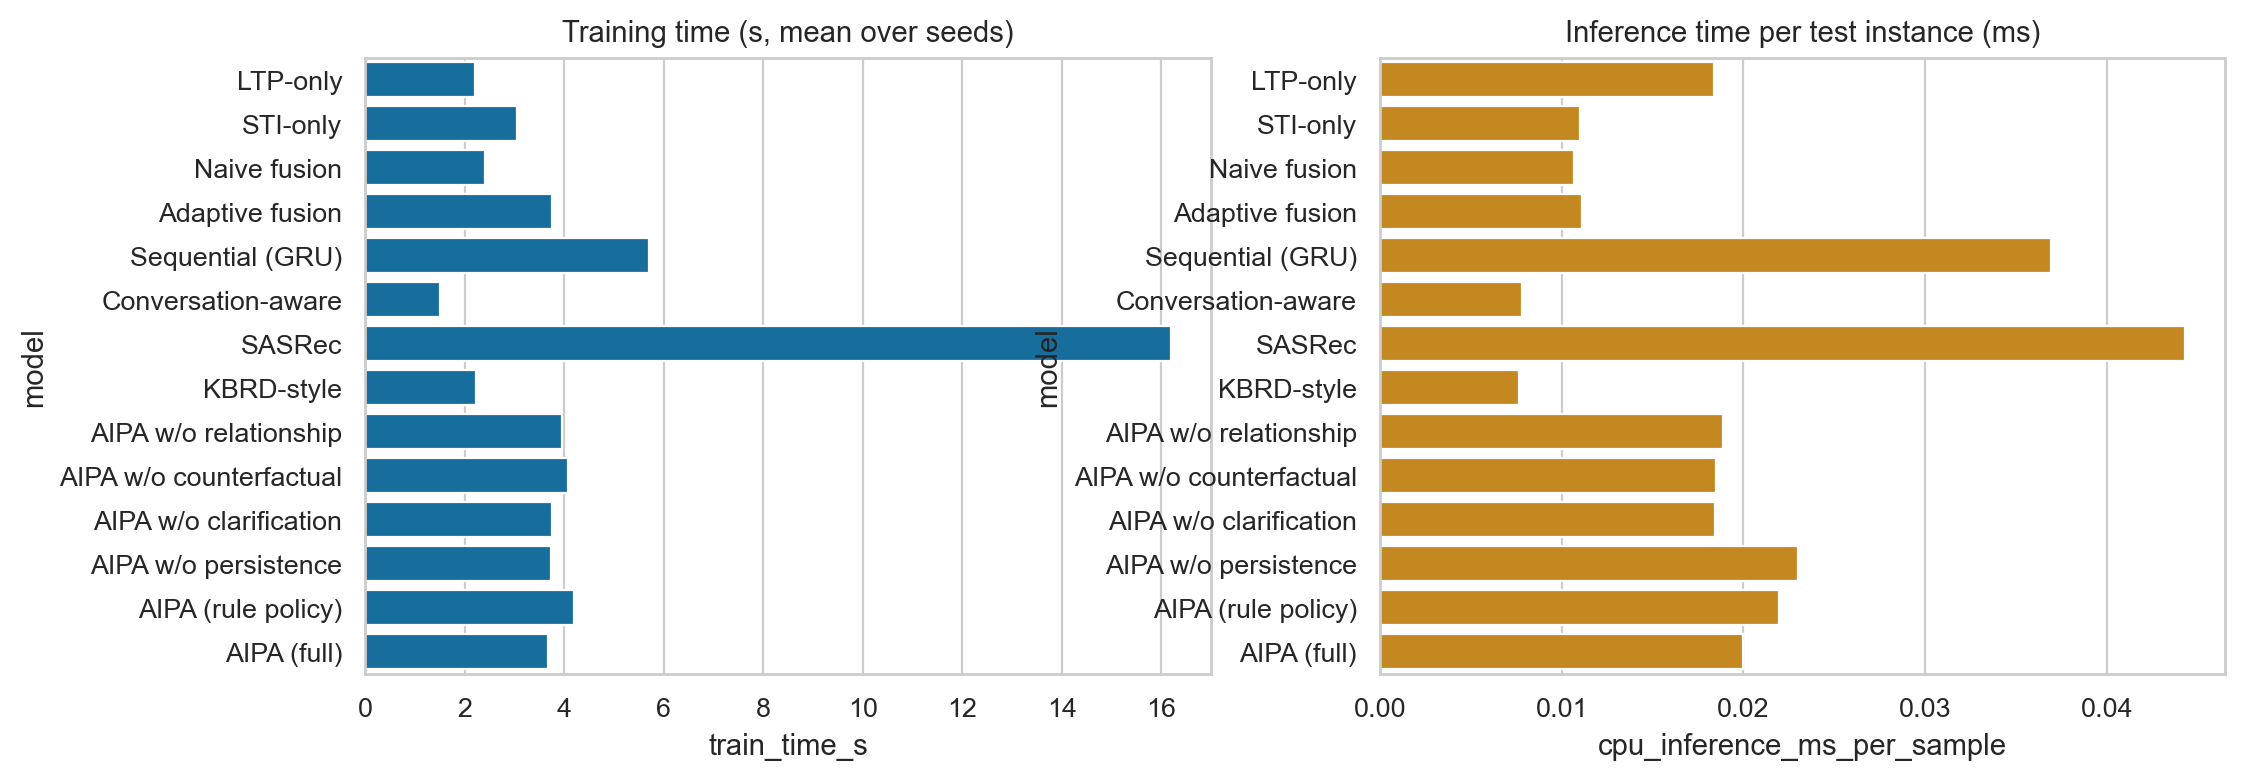

**fig00_architecture**

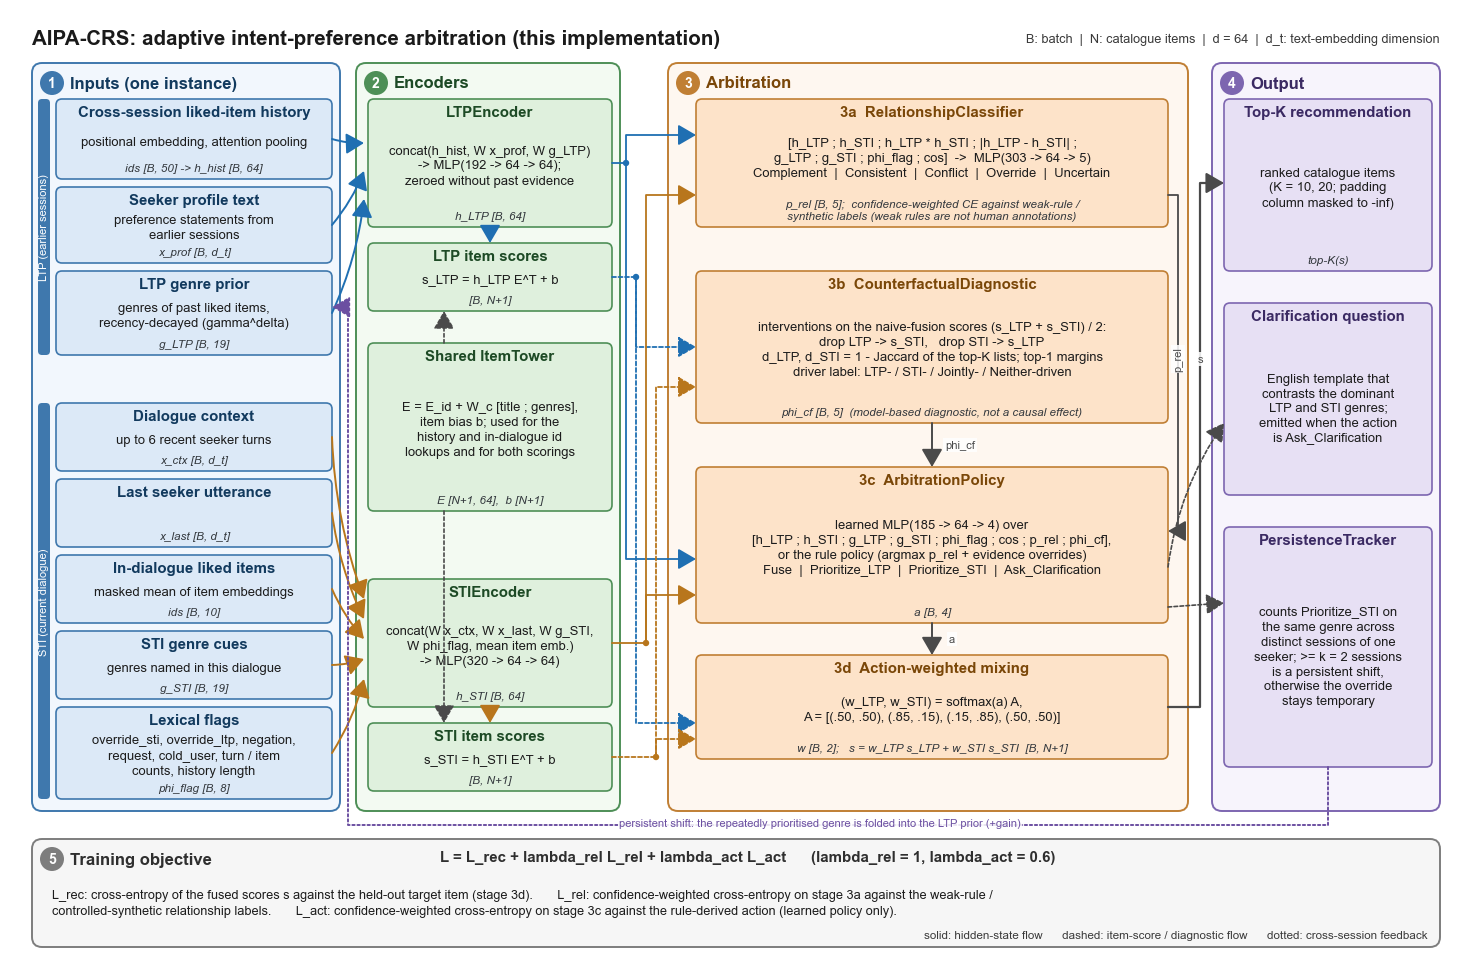

**fig00_architecture_compact**

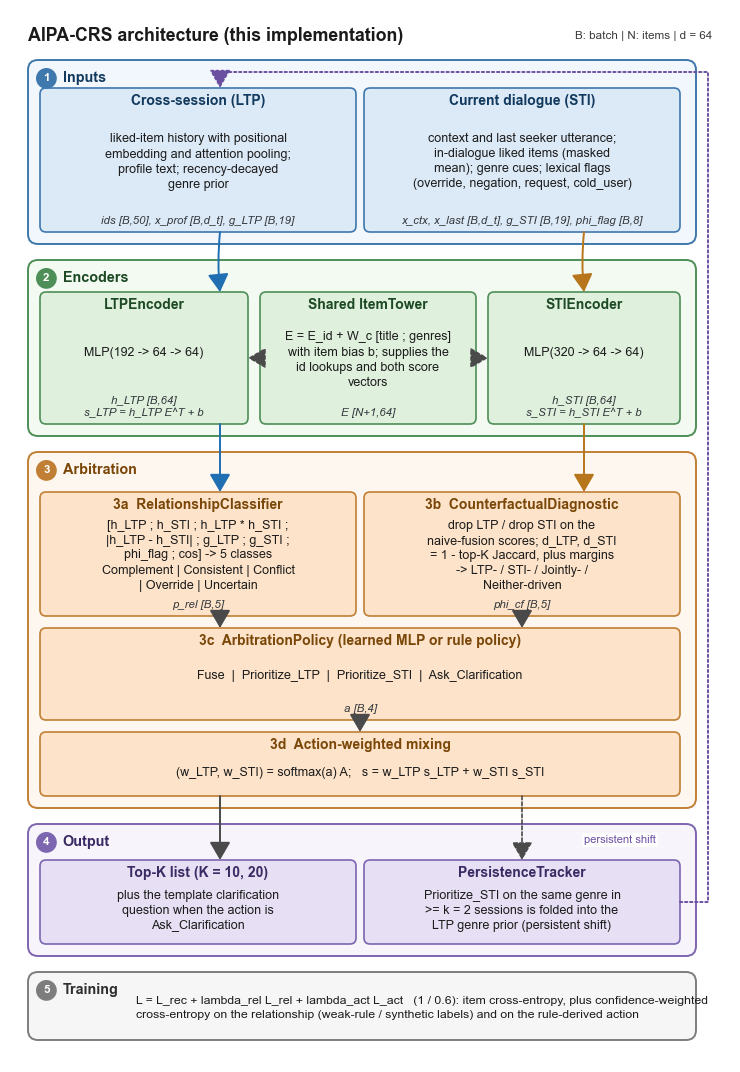

In [16]:
from aipa.figures import make_all
figs = make_all(res, stats, genre_frame(ds), per_seeker_frame(ds))
for k, p in figs.items():
    display(Markdown(f"**{k}**")); display(Image(filename=str(p), width=900))

## 8. Qualitative case studies (>= 10) and automated error analysis

In [17]:
cs = T["case_studies"]
for i, r in cs.iterrows():
    display(Markdown(f"**Case {i+1}** - `{r.sample_id}` ({'synthetic' if r.is_synthetic else 'natural'}; seeker {r.seeker_id})  \n"
                     f"*Dialogue:* {r.dialogue_excerpt}  \n*LTP* (history={r.ltp_history_len}): {r.ltp_profile}  \n*STI:* {r.sti_signal}  \n"
                     f"*Reference:* {r.reference_relationship} ({r.reference_source}) - *predicted:* {r.predicted_relationship} (conf {r.relationship_confidence})  \n"
                     f"*Arbitration:* **{r.arbitration_action}** (w_LTP={r.w_ltp}, w_STI={r.w_sti}); *driver:* {r.counterfactual_driver}  \n"
                     + (f"*Clarification:* _{r.clarification}_  \n" if r.clarification else "")
                     + f"*Target:* {r.target} (rank {r.target_rank}, hit@10={r['hit@10']}); *top-5:* {r.top5}"))
display(T["error_analysis"].round(3))

**Case 1** - `21414/7/170059` (natural; seeker 1034)  
*Dialogue:* Recommender: Yes great decade for actions! | Seeker: Oh course! :) | Seeker: I really liked True Lies (1994) and Speed  (1994) | Seeker: What do you think?  
*LTP* (history=50): Drama 0.24; Comedy 0.17; Romance 0.16  
*STI:* Action 0.63; Romance 0.13; Thriller 0.13  
*Reference:* Complement (weak_rule) - *predicted:* Consistent (conf 0.69)  
*Arbitration:* **Fuse** (w_LTP=0.49, w_STI=0.51); *driver:* STI-driven  
*Target:* Die Hard 2 (1990) (rank 961, hit@10=False); *top-5:* Black Panther (2018); The Avengers  (2012); John Wick (2014); Inception (2010); Die Hard (1988)

**Case 2** - `21394/3/140335` (natural; seeker 1034)  
*Dialogue:* Recommender: Hi | Recommender: What kind of movies do you like? | Seeker: Hiya. I like rom-com movies. Can you recommend any?  
*LTP* (history=50): Drama 0.24; Thriller 0.16; Mystery 0.11  
*STI:* Comedy 0.50; Romance 0.50  
*Reference:* Consistent (weak_rule) - *predicted:* Consistent (conf 0.383)  
*Arbitration:* **Fuse** (w_LTP=0.39, w_STI=0.61); *driver:* Jointly-driven  
*Target:* Knocked Up (2007) (rank 13, hit@10=False); *top-5:* 50 First Dates (2004); Girls Trip (2017); Forrest Gump (1994); A Bad Moms Christmas (2017); 10 Things I Hate About You (1999)

**Case 3** - `20721/8/93013` (natural; seeker 1009)  
*Dialogue:* Seeker: Yes, I loved it | Seeker: I love movies with Will Ferrell too, like Anchorman | Recommender: What about Jumanji  (2017) | Seeker: Oh, I haven't seen Jumanji  (2017) but I did see the older Jumanji (1995) and loved it.  
*LTP* (history=4): Crime 0.38; Drama 0.38; Film-Noir 0.09  
*STI:* Comedy 0.58; Adventure 0.08; Children 0.08  
*Reference:* Conflict (weak_rule) - *predicted:* Consistent (conf 0.514)  
*Arbitration:* **Fuse** (w_LTP=0.41, w_STI=0.59); *driver:* Jointly-driven  
*Target:* Daddy's Home  (2015) (rank 334, hit@10=False); *top-5:* Jumanji  (2017); Wonder Woman  (2017); Hot Fuzz (2007); Wonder  (2017); The House  (2017)

**Case 4** - `22721/3/98740` (natural; seeker 1087)  
*Dialogue:* Recommender: hi there! I would like to reccomend some movies to ya. What kind of movies do you like? | Seeker: I;d like to see some war movies this weekend similar to Dunkirk  (2017) , Darkest Hour  (2017) , Atonement  (2007) | Recommender: Oh okay!  
*LTP* (history=50): Comedy 0.26; Drama 0.22; Romance 0.13  
*STI:* War 0.68; Drama 0.18; Romance 0.06  
*Reference:* Override (weak_rule) - *predicted:* Override (conf 0.818)  
*Arbitration:* **Prioritize_STI** (w_LTP=0.22, w_STI=0.78); *driver:* STI-driven  
*Target:* Enemy at the Gates (2001) (rank 2120, hit@10=False); *top-5:* Dunkirk  (2017); Schindler's List (1993); Saving Private Ryan (1998); Black Hawk Down  (2002); Pearl Harbor  (2001)

**Case 5** - `22009/2/98259` (natural; seeker 1035)  
*Dialogue:* Recommender: Hello! How are you | Seeker: I'm good!  My brother is coming to visit and I want to queue up some good old fashioned monster movies for him.  Any suggestions?  
*LTP* (history=9): Comedy 0.28; Horror 0.18; Sci-Fi 0.17  
*STI:* (no genre cue)  
*Reference:* Uncertain (weak_rule) - *predicted:* Uncertain (conf 0.816)  
*Arbitration:* **Ask_Clarification** (w_LTP=0.54, w_STI=0.46); *driver:* Jointly-driven  
*Clarification:* _You usually go for comedy movies. Would you like something similar, or are you in the mood for a change?_  
*Target:* Monster  (2003) (rank 4789, hit@10=False); *top-5:* Black Panther (2018); Wonder Woman  (2017); Deadpool  (2016); Jumanji  (2017); The Shape of Water  (2017)

...

**Case 9** - `syn/con3/21868/11/116125` (synthetic; seeker 1053)  
*Dialogue:* Seeker: Oh those bring back good memories | Seeker: I can watch those again | Seeker: How about a few more? | Seeker: I really want a horror movie, not a comedy movie.  
*LTP* (history=50): Comedy 0.37; Action 0.24; Crime 0.12  
*STI:* Horror 0.92; Comedy 0.08  
*Reference:* Conflict (synthetic_controlled) - *predicted:* Conflict (conf 0.704)  
*Arbitration:* **Prioritize_STI** (w_LTP=0.24, w_STI=0.76); *driver:* STI-driven  
*Target:* Insidious  (2010) (rank 16, hit@10=False); *top-5:* It  (2017); The Exorcist  (1973); Get Out (2017); Annabelle  (2014); A Nightmare on Elm Street (1984)

**Case 10** - `syn/ove2/21905/3/141578` (synthetic; seeker 959)  
*Dialogue:* Recommender: hi | Seeker: Hello | Seeker: I am open to all movie types.  What would you suggest? | Seeker: Tonight I am in the mood for a world war film.  
*LTP* (history=50): Comedy 0.34; Horror 0.29; Thriller 0.13  
*STI:* War 1.00  
*Reference:* Override (synthetic_controlled) - *predicted:* Override (conf 0.931)  
*Arbitration:* **Prioritize_STI** (w_LTP=0.21, w_STI=0.79); *driver:* STI-driven  
*Target:* Lawrence of Arabia  (1962) (rank 510, hit@10=False); *top-5:* Schindler's List (1993); Black Hawk Down  (2002); Dunkirk  (2017); Hacksaw Ridge; Saving Private Ryan (1998)

**Case 11** - `21223/9/161313` (natural; seeker 1022)  
*Dialogue:* Recommender: Oh excellent | Recommender: How about The Other Guys (2010) or Get Hard (2015) | Seeker: I saw them | Seeker: nice movie though  
*LTP* (history=50): Action 0.24; Adventure 0.18; Sci-Fi 0.14  
*STI:* Action 0.50; Comedy 0.50  
*Reference:* Consistent (weak_rule) - *predicted:* Consistent (conf 0.844)  
*Arbitration:* **Fuse** (w_LTP=0.5, w_STI=0.5); *driver:* Jointly-driven  
*Target:* Die Hard (1988) (rank 7, hit@10=True); *top-5:* Black Panther (2018); Wonder Woman  (2017); Inception (2010); Thor: Ragnarok (2017); Jumanji  (2017)

**Case 12** - `22087/10/168161` (natural; seeker 959)  
*Dialogue:* Seeker: Oh that sounds like fun. | Recommender: Or even a classic/cheesy action film like The Rock  (1996) ? | Recommender: Something quotable like Anchorman | Seeker: Oh yes I think everyone would enjoy that too.  
*LTP* (history=50): Comedy 0.20; Animation 0.15; Children 0.13  
*STI:* (no genre cue)  
*Reference:* Uncertain (weak_rule) - *predicted:* Uncertain (conf 0.822)  
*Arbitration:* **Ask_Clarification** (w_LTP=0.54, w_STI=0.46); *driver:* Jointly-driven  
*Clarification:* _You usually go for comedy movies. Would you like something similar, or are you in the mood for a change?_  
*Target:* Clue  (1985) (rank 1056, hit@10=False); *top-5:* Jumanji  (2017); Black Panther (2018); Wonder Woman  (2017); Get Out (2017); Saving Private Ryan (1998)

,subset,relationship_label,n,miss_rate@10,relationship_error_rate,clarification_rate,mean_target_rank,median_target_rank,cold_seeker_share
0,natural,Complement,165,0.909,0.748,0.00,1246.873,427.0,0.000
1,natural,Conflict,48,0.917,0.812,0.00,1214.896,348.0,0.000
2,natural,Consistent,514,0.896,0.121,0.00,1073.347,310.0,0.000
3,natural,Override,14,0.821,0.214,0.00,1138.071,205.0,0.000
4,natural,Uncertain,336,0.918,0.094,0.64,1308.496,449.0,0.327
5,synthetic,Complement,31,0.855,0.323,0.00,476.032,111.0,0.000
6,synthetic,Conflict,33,0.758,0.106,0.00,276.212,55.0,0.000
7,synthetic,Consistent,24,0.958,0.000,0.00,1177.729,493.5,0.000
8,synthetic,Override,24,0.771,0.021,0.00,132.646,26.5,0.000
9,synthetic,Uncertain,31,0.855,0.000,1.00,1252.452,706.0,0.000


## 9. Tables, automatic report and hypothesis verdicts

All tables are written to `outputs/tables/` (CSV + Markdown) and the full report to `outputs/reports/AIPA_CRS_Experimental_Report.{md,html}`. Verdicts are derived mechanically from the paired tests (Holm-corrected Wilcoxon on per-instance Hit@10, alpha = 0.05).

In [18]:
from aipa.pipeline import write_tables, validate_components
from aipa.report import build_report
write_tables(res)
md_path, html_path = build_report(res, figs, None, stats)
validation = validate_components(res, figs, (md_path, html_path))
md_path, html_path = build_report(res, figs, validation, stats)
validation.to_csv(cfg.path("output_path") / "results" / "component_validation.csv", index=False)
text = md_path.read_text()
start = text.index("## 13. Hypothesis verdicts"); end = text.index("## 14.")
display(Markdown(text[start:end]))
print("report:", md_path, html_path)

## 13. Hypothesis verdicts

| hypothesis | comparison | verdict | mean_diff | p_holm |
|---|---|---|---|---|
| H1 (overall) | AIPA (full) vs LTP-only | SUPPORTED | 0.0381 | 0.0124 |
| H1 (overall) | AIPA (full) vs STI-only | NOT SUPPORTED (difference not significant) | -0.0149 | 1.0000 |
| H1 (overall) | AIPA (full) vs Naive fusion | NOT SUPPORTED (difference not significant) | 0.0023 | 1.0000 |
| H1 (overall) | AIPA (full) vs Adaptive fusion | NOT SUPPORTED (difference not significant) | 0.0121 | 1.0000 |
| H1 (overall) | AIPA (full) vs Sequential (GRU) | NOT SUPPORTED (difference not significant) | 0.0325 | 0.0531 |
| H1 (overall) | AIPA (full) vs Conversation-aware | NOT SUPPORTED (difference not significant) | 0.0130 | 1.0000 |
| H1 (overall) | AIPA (full) vs SASRec | SUPPORTED | 0.0385 | 0.0122 |
| H1 (overall) | AIPA (full) vs KBRD-style | NOT SUPPORTED (difference not significant) | -0.0037 | 1.0000 |
| H2 (conflict_natural_strict) | AIPA (full) vs LTP-only | NOT SUPPORTED (difference not significant) | 0.0887 | 0.8922 |
| H2 (conflict_natural_strict) | AIPA (full) vs STI-only | NOT SUPPORTED (difference not significant) | -0.0323 | 1.0000 |
| H2 (conflict_natural_strict) | AIPA (full) vs Naive fusion | NOT SUPPORTED (difference not significant) | 0.0242 | 1.0000 |
| H2 (conflict_natural_strict) | AIPA (full) vs Adaptive fusion | NOT SUPPORTED (difference not significant) | -0.0081 | 1.0000 |
| H2 (conflict_natural_strict) | AIPA (full) vs SASRec | NOT SUPPORTED (difference not significant) | 0.0806 | 1.0000 |
| H2 (conflict_natural_strict) | AIPA (full) vs KBRD-style | NOT SUPPORTED (difference not significant) | 0.0000 | 1.0000 |
| H2 (conflict_natural_broad) | AIPA (full) vs LTP-only | SUPPORTED | 0.0703 | 0.0456 |
| H2 (conflict_natural_broad) | AIPA (full) vs STI-only | NOT SUPPORTED (difference not significant) | -0.0137 | 1.0000 |
| H2 (conflict_natural_broad) | AIPA (full) vs Naive fusion | NOT SUPPORTED (difference not significant) | 0.0254 | 1.0000 |
| H2 (conflict_natural_broad) | AIPA (full) vs Adaptive fusion | NOT SUPPORTED (difference not significant) | 0.0195 | 1.0000 |
| H2 (conflict_natural_broad) | AIPA (full) vs SASRec | NOT SUPPORTED (difference not significant) | 0.0684 | 0.0570 |
| H2 (conflict_natural_broad) | AIPA (full) vs KBRD-style | NOT SUPPORTED (difference not significant) | -0.0117 | 1.0000 |
| H2 (conflict_synthetic) | AIPA (full) vs LTP-only | SUPPORTED | 0.1842 | 0.0150 |
| H2 (conflict_synthetic) | AIPA (full) vs STI-only | NOT SUPPORTED (difference not significant) | 0.0088 | 1.0000 |
| H2 (conflict_synthetic) | AIPA (full) vs Naive fusion | NOT SUPPORTED (difference not significant) | 0.0088 | 1.0000 |
| H2 (conflict_synthetic) | AIPA (full) vs Adaptive fusion | NOT SUPPORTED (difference not significant) | 0.0088 | 1.0000 |
| H2 (conflict_synthetic) | AIPA (full) vs SASRec | SUPPORTED | 0.1842 | 0.0160 |
| H2 (conflict_synthetic) | AIPA (full) vs KBRD-style | NOT SUPPORTED (difference not significant) | 0.0000 | 1.0000 |
| H4 (relationship classifier) | macro-F1 on natural (weak labels) | SUPPORTED | 0.5402 | n/a |
| H4 (relationship classifier) | macro-F1 on synthetic (controlled) | SUPPORTED | 0.8991 | n/a |

### Objective conclusion

H1 (overall improvement) is supported in 2/8 baseline comparisons and contradicted in 0. H2 (conflict-specific gain) is supported in 3/18 comparisons and contradicted in 0. The evidence is consistent with the central claim that arbitration helps *specifically* under conflict, although it rests partly on weak or synthetic labels. Quick mode uses a data subset and few epochs; these verdicts are provisional.



report: /Users/dhaya/PhD/Learnings/AIPA-CRS/AIPA-CRS/outputs/reports/AIPA_CRS_Experimental_Report.md /Users/dhaya/PhD/Learnings/AIPA-CRS/AIPA-CRS/outputs/reports/AIPA_CRS_Experimental_Report.html


## 10. Final validation (PASS / FAIL / NOT RUN per component)

In [19]:
display(validation)
n_fail = int((validation.status == "FAIL").sum()); n_nr = int((validation.status == "NOT RUN").sum())
print(f"total runtime: {(time.perf_counter() - T0) / 60:.1f} min  |  PASS={int((validation.status == 'PASS').sum())} FAIL={n_fail} NOT RUN={n_nr}")
print("OVERALL:", "PASS" if n_fail == 0 else "FAIL")

,component,status,note
0,dataset acquisition & validation,PASS,4 files hashed
1,instance construction (leak-free),PASS,"train=9342, test=1220"
2,weak-rule relationship labels,PASS,
3,controlled synthetic injection,PASS,143 synthetic test instances
4,human-verified labels,NOT RUN,NOT RUN (no data/annotations/human_verified.csv provided)
5,baseline: LTP-only,PASS,
6,baseline: STI-only,PASS,
7,baseline: Naive fusion,PASS,
8,baseline: Adaptive fusion,PASS,
9,baseline: Sequential (GRU),PASS,


total runtime: 7.8 min  |  PASS=40 FAIL=0 NOT RUN=1
OVERALL: PASS


## 11. Limitations (read before citing any number)

1. **Labels** - natural relationship labels are weak heuristics; relationship metrics on natural data measure agreement with these heuristics, not with human judgement. Synthetic Conflict/Override instances are explicitly marked and evaluated separately; their targets are sampled intent-matching items.
2. **LTP proxy** - ReDial seekers are crowd workers; cross-session history across their dialogues stands in for genuine long-term preference, and `conversationId` order is assumed chronological.
3. **Baselines** - approximate re-implementations; no claim of reproducing MRGE, DiffLSRec or other published systems.
4. **Counterfactuals** - interventions on the trained model, not causal effects on users.
5. **Quick mode** - subset + few epochs; run `RUN_MODE = "full"` before drawing publication-level conclusions. Negative or inconclusive verdicts above are reported as such.